<a href="https://colab.research.google.com/github/aleferpue/TFG-TDA-aplicado-al-Modelo-de-Kuramoto/blob/main/TFG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
!pip install ripser persim
from ripser import ripser
from persim import plot_diagrams

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 843.4/843.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.2 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=1e49659ae9b95e7e23a00889e76415d7ecdbf6ead05a978cdf5c7af835dae7ca
  Stored in directory: /root/.cache/pip/wheels/2a/fd/fe/f4b8fd82894e1d9e04040ef41dc5ae6eb7a8e9b0ef5a9402fe
Successfully built hopcroftkarp


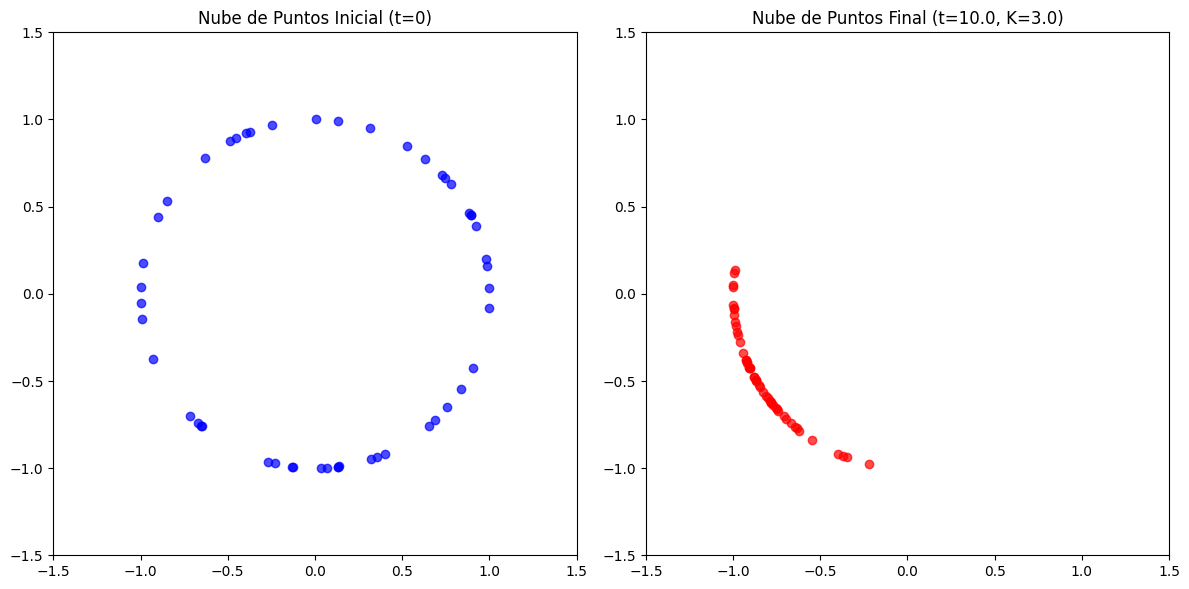

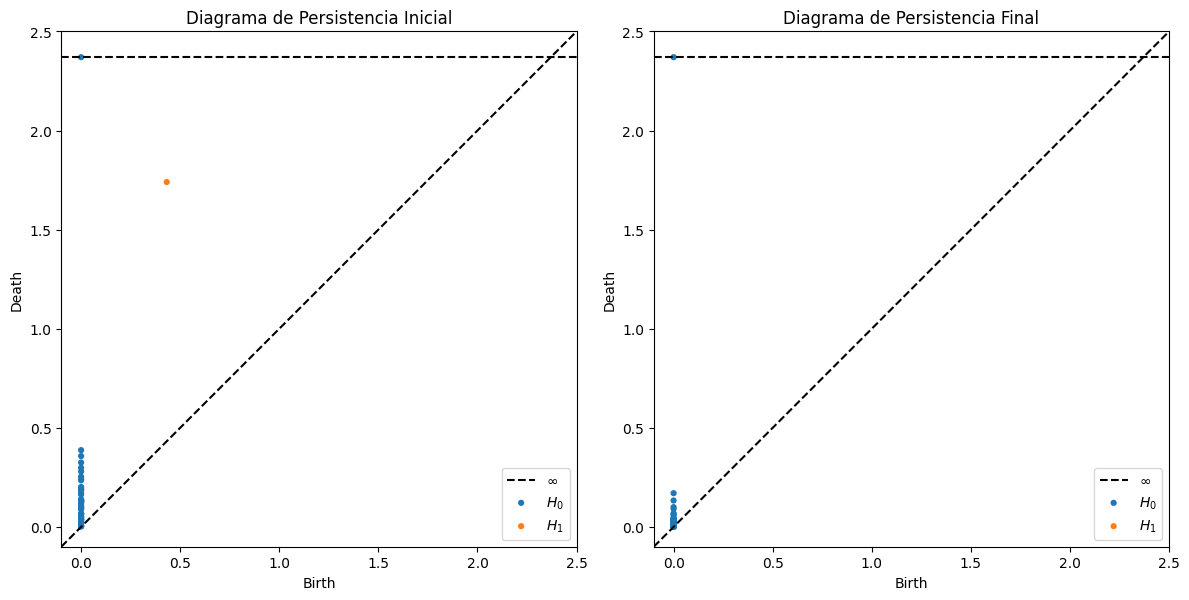

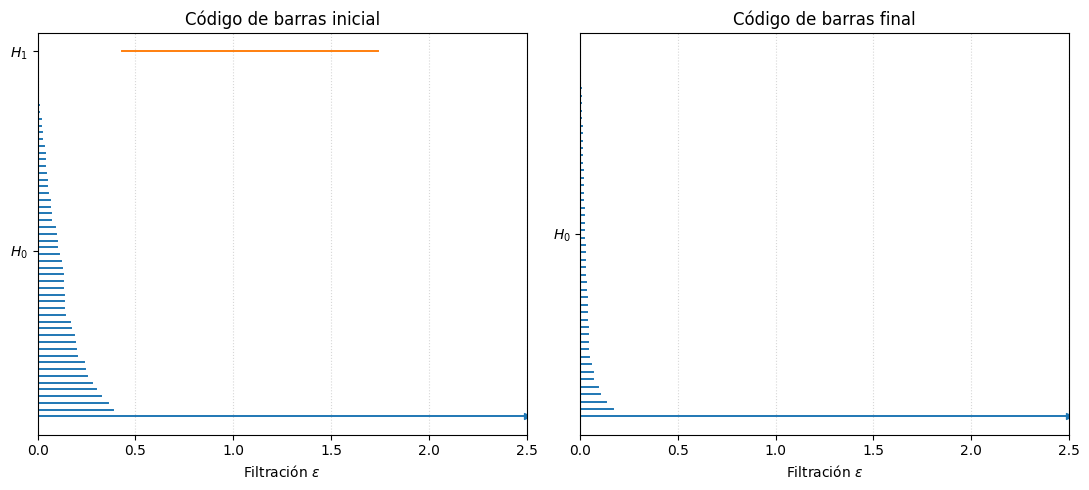

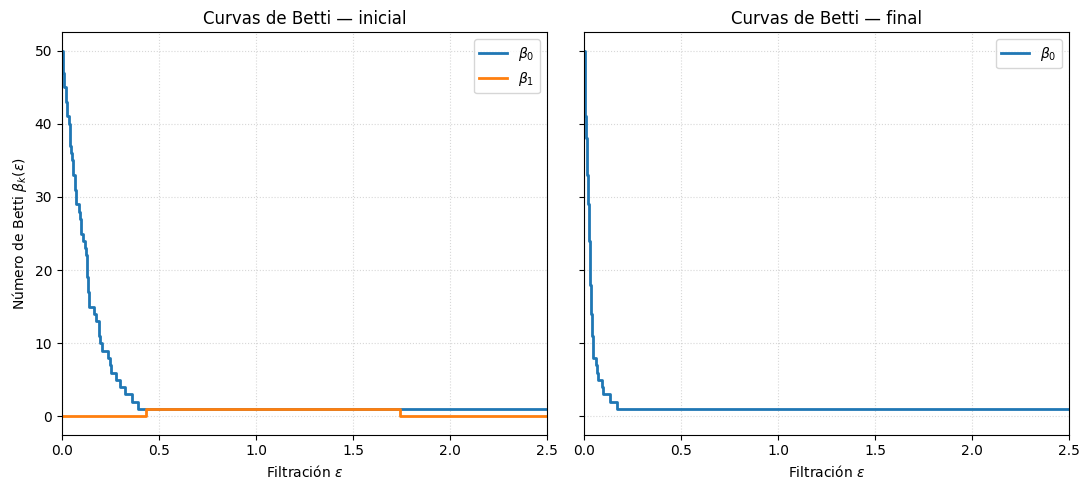

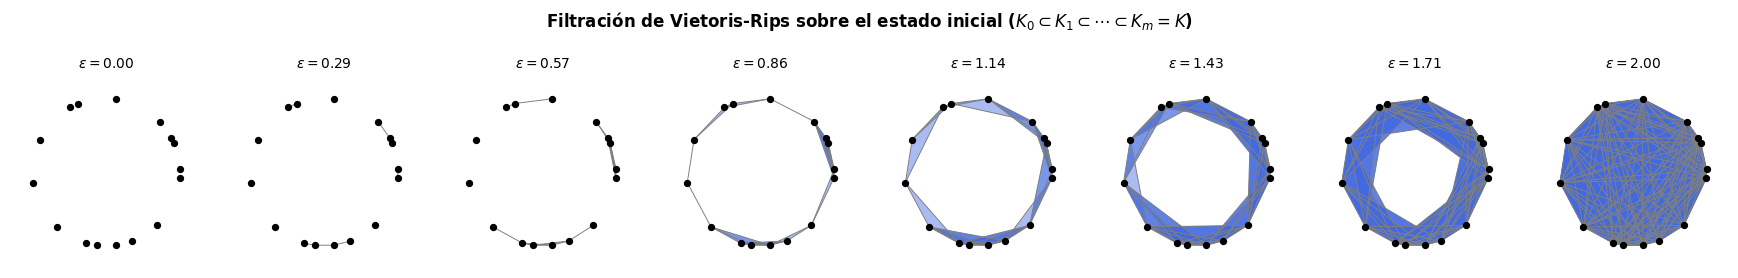

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.spatial.distance import pdist, squareform
from ripser import ripser
from persim import plot_diagrams

# ==========================================
# 1. PARÁMETROS DEL MODELO DE KURAMOTO
# ==========================================
N = 50           # Número de osciladores
K = 3.0          # Parámetro de acoplamiento (suficiente para sincronizar)
dt = 0.05        # Paso de tiempo
steps = 200      # Número de iteraciones

# Frecuencias naturales extraídas de una distribución normal
np.random.seed(42)
omega = np.random.normal(0, 1, N)

# Fases iniciales aleatorias entre 0 y 2*pi (Estado Desincronizado)
theta_inicial = np.random.uniform(0, 2 * np.pi, N)
theta = np.copy(theta_inicial)

# ==========================================
# 2. SIMULACIÓN NUMÉRICA (MÉTODO DE EULER)
# ==========================================
historia_theta = np.zeros((steps, N))
for t in range(steps):
    historia_theta[t] = theta
    dtheta = np.zeros(N)
    for i in range(N):
        interaccion = np.sum(np.sin(theta - theta[i]))
        dtheta[i] = omega[i] + (K / N) * interaccion
    theta = theta + dtheta * dt
    theta = np.mod(theta, 2 * np.pi)

theta_final = theta

# ==========================================
# 3. TRANSFORMACIÓN A NUBE DE PUNTOS (R^2)
# ==========================================
def fases_a_puntos(fases):
    return np.column_stack((np.cos(fases), np.sin(fases)))

puntos_iniciales = fases_a_puntos(theta_inicial)
puntos_finales = fases_a_puntos(theta_final)

# ==========================================
# 4. ANÁLISIS TOPOLÓGICO DE DATOS (RIPSER)
# ==========================================
dgms_inicial = ripser(puntos_iniciales, maxdim=1)['dgms']
dgms_final = ripser(puntos_finales, maxdim=1)['dgms']

# Colores por dimensión homológica (coherentes con persim)
COLORES_DIM = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green'}
ETIQUETAS_DIM = {0: r'$H_0$', 1: r'$H_1$', 2: r'$H_2$'}

# Rango común en epsilon para que TODAS las gráficas sean 100% comparables
XMAX = 2.5
RANGO_DGM = [-0.1, XMAX, -0.1, XMAX]   # [xmin, xmax, ymin, ymax] para plot_diagrams

# ==========================================
# 5a. FIGURA 1 — NUBES DE PUNTOS (inicial y final, lado a lado)
# ==========================================
fig_nubes, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].scatter(puntos_iniciales[:, 0], puntos_iniciales[:, 1], c='blue', alpha=0.7)
axs[0].set_title("Nube de Puntos Inicial (t=0)")
axs[0].set_xlim([-1.5, 1.5]); axs[0].set_ylim([-1.5, 1.5])
axs[0].set_aspect('equal')

axs[1].scatter(puntos_finales[:, 0], puntos_finales[:, 1], c='red', alpha=0.7)
axs[1].set_title(f"Nube de Puntos Final (t={steps*dt:.1f}, K={K})")
axs[1].set_xlim([-1.5, 1.5]); axs[1].set_ylim([-1.5, 1.5])
axs[1].set_aspect('equal')

fig_nubes.tight_layout()

# ==========================================
# 5b. FIGURA 2 — DIAGRAMAS DE PERSISTENCIA (inicial y final, lado a lado)
#     (corregidos con xy_range para fijar la escala desde la propia función)
# ==========================================
fig_dgms, axs = plt.subplots(1, 2, figsize=(12, 6))

plt.sca(axs[0])
plot_diagrams(dgms_inicial, show=False, xy_range=RANGO_DGM)
axs[0].set_title("Diagrama de Persistencia Inicial")

plt.sca(axs[1])
plot_diagrams(dgms_final, show=False, xy_range=RANGO_DGM)
axs[1].set_title("Diagrama de Persistencia Final")

fig_dgms.tight_layout()

plt.show()

# ==========================================
# 6. FIGURA 2 — CÓDIGOS DE BARRAS (mismo rango XMAX para ambos)
# ==========================================
def plot_barcode(dgms, ax, titulo, xmax):
    """Dibuja el código de barras de persistencia, una barra por intervalo.
    Las barras infinitas se extienden hasta xmax y se marcan con una flecha."""
    y = 0
    yticks, ylabels = [], []
    for dim, dgm in enumerate(dgms):
        if len(dgm) == 0:
            continue
        # Ordenar de mayor a menor persistencia (las más largas, arriba)
        orden = np.argsort(-(dgm[:, 1] - dgm[:, 0]))
        y_ini = y
        for idx in orden:
            b, d = dgm[idx]
            d_plot = d if np.isfinite(d) else xmax
            ax.plot([b, d_plot], [y, y], color=COLORES_DIM[dim], lw=1.4)
            if not np.isfinite(d):  # marcar las barras infinitas
                ax.scatter(xmax, y, marker='>', s=18, color=COLORES_DIM[dim])
            y += 1
        yticks.append((y_ini + y - 1) / 2)
        ylabels.append(ETIQUETAS_DIM[dim])
        y += 4  # separación entre dimensiones
    ax.set_yticks(yticks); ax.set_yticklabels(ylabels)
    ax.set_xlim(0, xmax)
    ax.set_xlabel(r"Filtración $\varepsilon$")
    ax.set_title(titulo)
    ax.grid(True, axis='x', linestyle=':', alpha=0.5)

fig2, axs = plt.subplots(1, 2, figsize=(11, 5))
plot_barcode(dgms_inicial, axs[0], "Código de barras inicial", XMAX)
plot_barcode(dgms_final, axs[1], "Código de barras final", XMAX)
fig2.tight_layout()

# ==========================================
# 7. FIGURA 3 — CURVAS DE BETTI (misma rejilla [0, XMAX])
# ==========================================
def curva_betti(dgm, eps_grid):
    """Número de clases vivas en cada escala: beta_k(eps) = #{(b,d): b <= eps < d}."""
    betti = np.zeros_like(eps_grid, dtype=float)
    for b, d in dgm:
        betti += (eps_grid >= b) & (eps_grid < d)
    return betti

eps_grid = np.linspace(0, XMAX, 500)

fig3, axs = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, dgms, titulo in [(axs[0], dgms_inicial, "Curvas de Betti — inicial"),
                         (axs[1], dgms_final, "Curvas de Betti — final")]:
    for dim, dgm in enumerate(dgms):
        if len(dgm) == 0:
            continue
        ax.plot(eps_grid, curva_betti(dgm, eps_grid), color=COLORES_DIM[dim],
                lw=2, label=r'$\beta_{%d}$' % dim, drawstyle='steps-post')
    ax.set_xlim(0, XMAX)
    ax.set_xlabel(r"Filtración $\varepsilon$")
    ax.set_title(titulo)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend()
axs[0].set_ylabel(r"Número de Betti $\beta_k(\varepsilon)$")
fig3.tight_layout()

# ==========================================
# 8. FIGURA 4 — FILTRACIÓN DE VIETORIS-RIPS SOBRE EL ESTADO INICIAL
# ==========================================
# Para que la filtración sea legible (como en la figura clásica) usamos pocos
# puntos: submuestreamos el estado inicial ordenándolo por ángulo.
n_filt = 16
idx_orden = np.argsort(theta_inicial)                      # ordenar por fase
idx_sub = idx_orden[np.linspace(0, N - 1, n_filt).astype(int)]
P = puntos_iniciales[idx_sub]
D = squareform(pdist(P))                                   # matriz de distancias

def dibujar_complejo_VR(points, D, eps, ax):
    """Dibuja el complejo de Vietoris-Rips a escala eps: vértices, aristas y
    2-símplices (triángulos rellenos). Un símplice entra cuando TODAS sus
    distancias por pares son <= eps (misma convención que Ripser)."""
    n = len(points)
    for i, j, k in combinations(range(n), 3):              # triángulos al fondo
        if D[i, j] <= eps and D[i, k] <= eps and D[j, k] <= eps:
            ax.add_patch(plt.Polygon(points[[i, j, k]], closed=True,
                                     facecolor='royalblue', alpha=0.45,
                                     edgecolor='none', zorder=1))
    for i, j in combinations(range(n), 2):                 # aristas
        if D[i, j] <= eps:
            ax.plot(points[[i, j], 0], points[[i, j], 1],
                    color='gray', lw=0.7, zorder=2)
    ax.scatter(points[:, 0], points[:, 1], s=18, color='black', zorder=3)  # vértices
    ax.set_title(rf"$\varepsilon = {eps:.2f}$", fontsize=10)
    ax.set_aspect('equal'); ax.axis('off')

eps_valores = np.linspace(0, D.max(), 8)   # K_0 ⊂ K_1 ⊂ ... ⊂ K_m

fig4, axs = plt.subplots(1, len(eps_valores), figsize=(2.2 * len(eps_valores), 2.6))
for ax, eps in zip(axs, eps_valores):
    dibujar_complejo_VR(P, D, eps, ax)
    ax.set_xlim([-1.3, 1.3]); ax.set_ylim([-1.3, 1.3])
fig4.suptitle(r"Filtración de Vietoris-Rips sobre el estado inicial "
              r"($K_0 \subset K_1 \subset \cdots \subset K_m = K$)",
              fontweight='bold', y=1.05)
fig4.tight_layout()

plt.show()

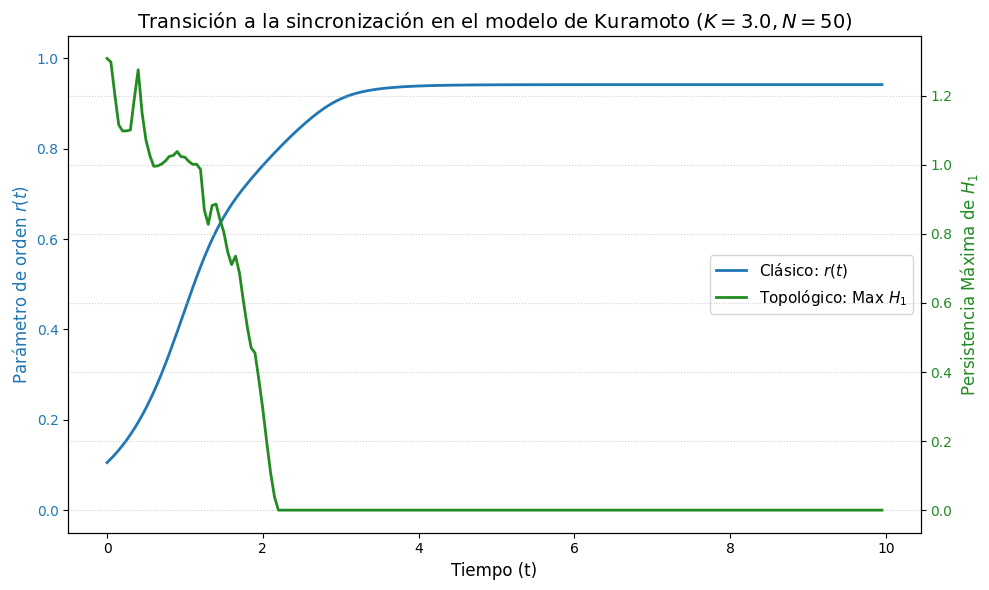

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser

# ==========================================
# 1. PARÁMETROS DEL MODELO DE KURAMOTO
# ==========================================
N = 50           # Número de osciladores
K = 3.0          # Parámetro de acoplamiento
dt = 0.05        # Paso de tiempo
steps = 200      # Número de iteraciones

# Frecuencias naturales (distribución normal)
np.random.seed(42)
omega = np.random.normal(0, 1, N)

# Fases iniciales aleatorias entre 0 y 2*pi (Estado Desincronizado)
theta_inicial = np.random.uniform(0, 2 * np.pi, N)
theta = np.copy(theta_inicial)

# ==========================================
# 2. INICIALIZACIÓN DE VARIABLES HISTÓRICAS
# ==========================================
# Arrays para guardar las métricas a lo largo del tiempo
historia_r = np.zeros(steps)
historia_H1_max = np.zeros(steps)

# ==========================================
# 3. SIMULACIÓN NUMÉRICA (MÉTODO DE EULER)
# ==========================================
for t in range(steps):

    # --- A) MEDIR EL ESTADO MACROSCÓPICO Y TOPOLÓGICO ACTUAL ---

    # Calcular parámetro de orden clásico r(t)
    r = np.abs(np.mean(np.exp(1j * theta)))
    historia_r[t] = r

    # Calcular topología H1
    # Convertimos fases a coordenadas cartesianas sobre el círculo unitario
    puntos = np.column_stack((np.cos(theta), np.sin(theta)))
    rips = ripser(puntos, maxdim=1)
    dgms = rips['dgms']

    # Extraer la persistencia máxima de H1
    if len(dgms[1]) > 0:
        # La persistencia es Muerte - Nacimiento (columna 1 - columna 0)
        persistencias = dgms[1][:, 1] - dgms[1][:, 0]
        # Filtrar posibles valores infinitos
        persistencias = persistencias[np.isfinite(persistencias)]
        if len(persistencias) > 0:
            historia_H1_max[t] = np.max(persistencias)
        else:
            historia_H1_max[t] = 0.0
    else:
        # Si no hay clases H1 (agujeros), la persistencia es 0
        historia_H1_max[t] = 0.0

    # --- B) EVOLUCIONAR EL SISTEMA AL SIGUIENTE INSTANTE ---

    # Calcular la derivada de la fase para cada oscilador
    dtheta = np.zeros(N)
    for i in range(N):
        # Ecuación de Kuramoto
        interaccion = np.sum(np.sin(theta - theta[i]))
        dtheta[i] = omega[i] + (K / N) * interaccion

    # Actualizar fases para la siguiente iteración (t+1)
    theta = theta + dtheta * dt
    # Mantener las fases en el intervalo [0, 2*pi]
    theta = np.mod(theta, 2 * np.pi)

# ==========================================
# 4. VISUALIZACIÓN ACADÉMICA
# ==========================================
tiempos = np.arange(steps) * dt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Configuración del eje Y izquierdo (Parámetro r(t))
color_r = '#1f77b4' # Azul estándar de matplotlib
ax1.set_xlabel('Tiempo (t)', fontsize=12)
ax1.set_ylabel('Parámetro de orden $r(t)$', color=color_r, fontsize=12)
linea1 = ax1.plot(tiempos, historia_r, color=color_r, linewidth=2, label='Clásico: $r(t)$')
ax1.tick_params(axis='y', labelcolor=color_r)
ax1.set_ylim([-0.05, 1.05]) # r(t) va de 0 a 1

# Configuración del eje Y derecho (Persistencia H1)
ax2 = ax1.twinx()
color_h1 = 'forestgreen' # Naranja estándar de matplotlib
ax2.set_ylabel('Persistencia Máxima de $H_1$', color=color_h1, fontsize=12)
linea2 = ax2.plot(tiempos, historia_H1_max, color=color_h1, linewidth=2, label='Topológico: Max $H_1$')
ax2.tick_params(axis='y', labelcolor=color_h1)

# Unificar las leyendas de ambos ejes
lineas = linea1 + linea2
etiquetas = [l.get_label() for l in lineas]
ax1.legend(lineas, etiquetas, loc='center right', fontsize=11)

# Ajustes finales de la gráfica
plt.title(f'Transición a la sincronización en el modelo de Kuramoto ($K={K}, N={N}$)', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
fig.tight_layout()

# Mostrar la gráfica
plt.show()

**EJEMPLO 2**

**KURAMOTO AUMENTADO**


In [ ]:
pip install numpy scipy matplotlib ripser persim

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 843.4/843.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.2 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=68f72e26ecce47f941fe39fc621d47af1bae46990e3af1650895fa77418dceae
  Stored in directory: /root/.cache/pip/wheels/2a/fd/fe/f4b8fd82894e1d9e04040ef41dc5ae6eb7a8e9b0ef5a9402fe
Successfully built hopcroftkarp


>> Simulando la dinámica en S^2 (Matriz Vectorizada)...
>> Simulación completada en 0.05 segundos.

>> Calculando homología persistente en paralelo para los 3 estados...
>> TDA completado en 80.05 segundos.


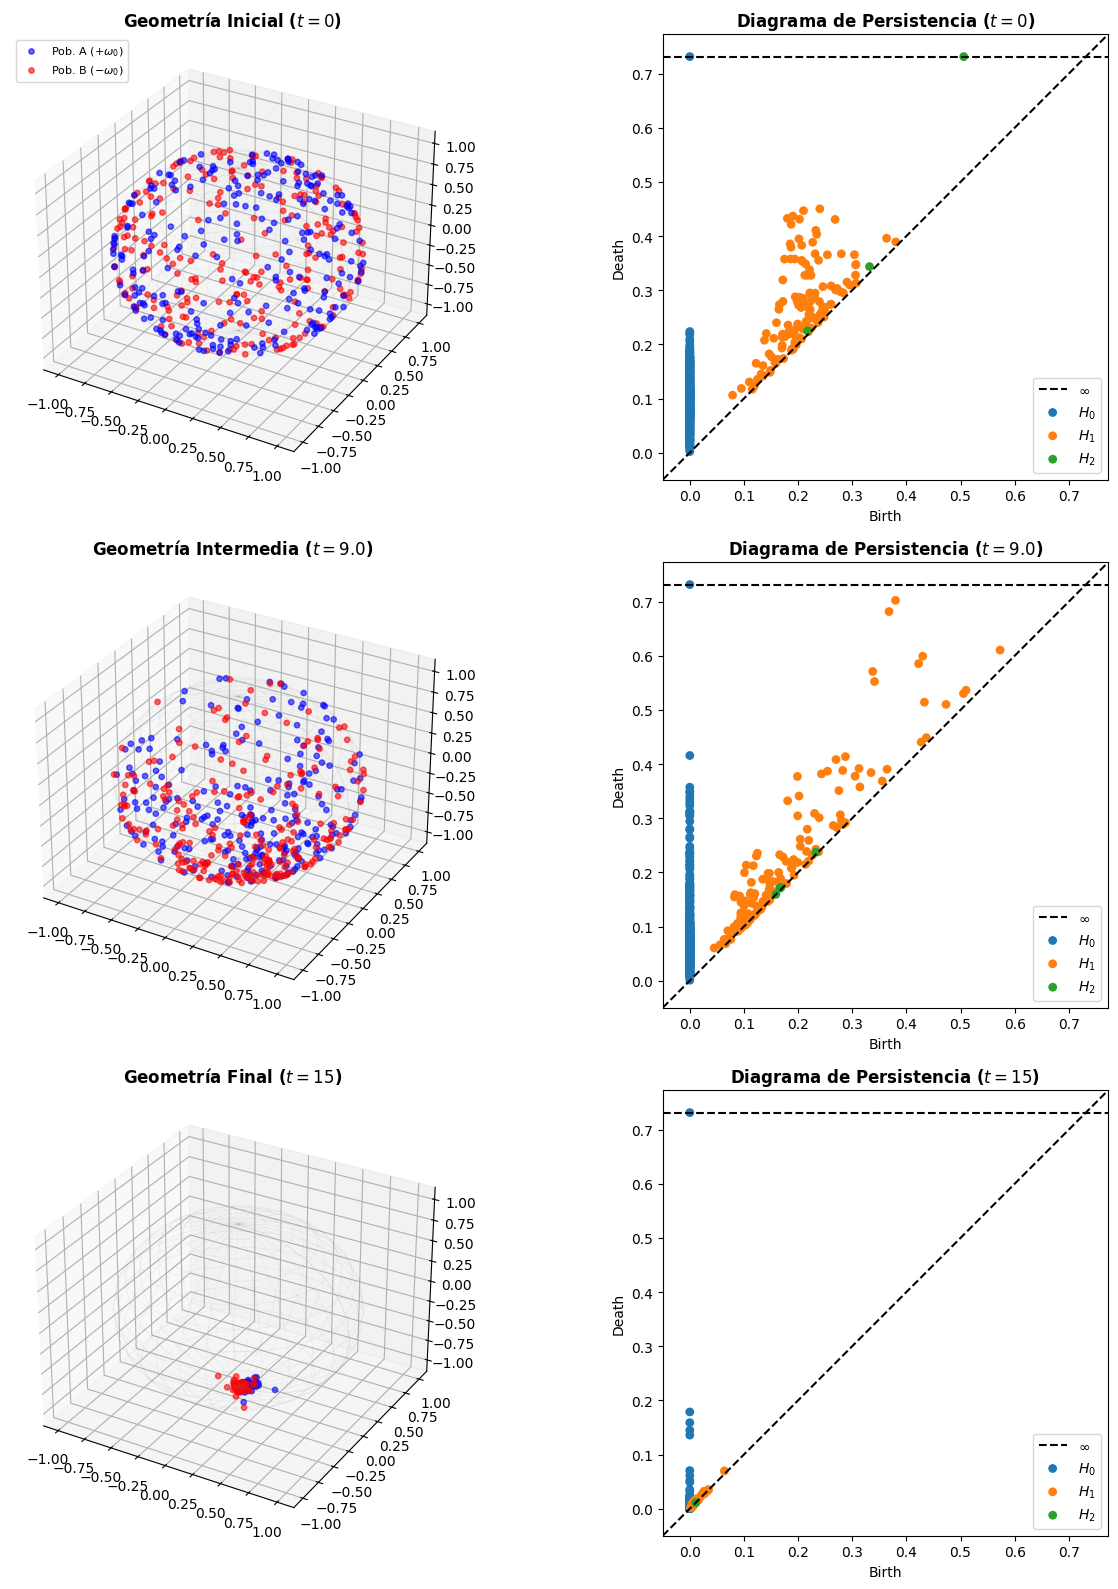

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ripser import ripser
from persim import plot_diagrams
from joblib import Parallel, delayed  # Optimizacion 2: Paralelizacion nativa
import time

# --- 1. PARÁMETROS DEL SISTEMA ---
N = 500
omega0 = 3.0
K = 0.7
t_span = (0, 15)
t_eval = np.linspace(t_span[0], t_span[1], 300)

frecuencias = np.ones(N)
frecuencias[:N//2] = omega0
frecuencias[N//2:] = -omega0

# --- 2. CONDICIONES INICIALES (Distribución uniforme en S^2) ---
np.random.seed(123)
u = np.random.normal(0, 1, (N, 3))
norm = np.linalg.norm(u, axis=1, keepdims=True)
V0 = (u / norm).flatten()

V_initial = V0.reshape((N, 3))

# --- 3. ECUACIÓN DIFERENCIAL COMPLETAMENTE VECTORIZADA ---
def lohe_dynamics_vectorized(t, v_flat, N, K, frecuencias):
    V = v_flat.reshape((N, 3))
    M = np.mean(V, axis=0)

    rot_x = -frecuencias * V[:, 1]
    rot_y = frecuencias * V[:, 0]
    rotation = np.column_stack((rot_x, rot_y, np.zeros_like(rot_x)))

    dot_products = V @ M
    coupling = K * (M - dot_products[:, np.newaxis] * V)

    dV_dt = rotation + coupling
    return dV_dt.flatten()

# --- 4. SIMULACIÓN ---
print(">> Simulando la dinámica en S^2 (Matriz Vectorizada)...")
t_start_sim = time.time()
sol = solve_ivp(lohe_dynamics_vectorized, t_span, V0, t_eval=t_eval, args=(N, K, frecuencias), method='RK45')
print(f">> Simulación completada en {time.time() - t_start_sim:.2f} segundos.")

intermediate_time_target = 9
intermediate_time_index = np.argmin(np.abs(t_eval - intermediate_time_target))
V_intermedio = sol.y[:, intermediate_time_index].reshape((N, 3))
V_final = sol.y[:, -1].reshape((N, 3))

# --- 5. ANÁLISIS TOPOLÓGICO PARALELIZADO Y ACOTADO ---
def calcular_tda_seguro(V_estado, nombre_estado):
    rips_res = ripser(V_estado, maxdim=2, thresh=1.4)
    return rips_res['dgms']

print("\n>> Calculando homología persistente en paralelo para los 3 estados...")
t_start_tda = time.time()

diagramas = Parallel(n_jobs=-1)(
    delayed(calcular_tda_seguro)(estado, nombre)
    for estado, nombre in [(V_initial, "inicial"), (V_intermedio, "intermedio"), (V_final, "final")]
)

dgms_initial, dgms_intermedio, dgms_final = diagramas
print(f">> TDA completado en {time.time() - t_start_tda:.2f} segundos.")

#  CALCULAR LÍMITE GLOBAL DE LOS EJES PARA TDA ---
def get_max_finite_death(dgms):
    """Encuentra el valor máximo de muerte finito en un diagrama."""
    max_d = 0.0
    for dgm in dgms:
        if len(dgm) > 0:
            finite_deaths = dgm[dgm[:, 1] != np.inf][:, 1]
            if len(finite_deaths) > 0:
                max_d = max(max_d, np.max(finite_deaths))
    return max_d

# Buscamos el máximo absoluto entre los tres tiempos
max_death_global = max(
    get_max_finite_death(dgms_initial),
    get_max_finite_death(dgms_intermedio),
    get_max_finite_death(dgms_final)
)

# Definimos el límite de los ejes con un margen del 10%
limite_ejes = max_death_global * 1.1
rango_global = [-0.05, limite_ejes, -0.05, limite_ejes]

# --- 6. VISUALIZACIÓN EN CUADRÍCULA 3X2 ---
fig = plt.figure(figsize=(14, 16))

u_mesh, v_mesh = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
x_sphere = np.cos(u_mesh) * np.sin(v_mesh)
y_sphere = np.sin(u_mesh) * np.sin(v_mesh)
z_sphere = np.cos(v_mesh)

# --- FILA 1: ESTADO INICIAL ---
ax1 = fig.add_subplot(321, projection='3d')
ax1.plot_wireframe(x_sphere, y_sphere, z_sphere, color='gray', alpha=0.1, linewidth=0.5)
ax1.scatter(V_initial[:N//2, 0], V_initial[:N//2, 1], V_initial[:N//2, 2], color='blue', s=15, alpha=0.6, label=r'Pob. A ($+\omega_0$)')
ax1.scatter(V_initial[N//2:, 0], V_initial[N//2:, 1], V_initial[N//2:, 2], color='red', s=15, alpha=0.6, label=r'Pob. B ($-\omega_0$)')
ax1.set_title("Geometría Inicial ($t = 0$)", fontweight='bold')
ax1.legend(loc='upper left', fontsize=8)

ax2 = fig.add_subplot(322)
# Añadimos xy_range a la función plot_diagrams
plot_diagrams(dgms_initial, show=False, ax=ax2, legend=True, xy_range=rango_global, size=40)
ax2.set_title("Diagrama de Persistencia ($t = 0$)", fontweight='bold')

# --- FILA 2: ESTADO INTERMEDIO ---
ax3 = fig.add_subplot(323, projection='3d')
ax3.plot_wireframe(x_sphere, y_sphere, z_sphere, color='gray', alpha=0.1, linewidth=0.5)
ax3.scatter(V_intermedio[:N//2, 0], V_intermedio[:N//2, 1], V_intermedio[:N//2, 2], color='blue', s=15, alpha=0.6)
ax3.scatter(V_intermedio[N//2:, 0], V_intermedio[N//2:, 1], V_intermedio[N//2:, 2], color='red', s=15, alpha=0.6)
ax3.set_title(f"Geometría Intermedia ($t = {t_eval[intermediate_time_index]:.1f}$)", fontweight='bold')

ax4 = fig.add_subplot(324)
# Añadimos xy_range
plot_diagrams(dgms_intermedio, show=False, ax=ax4, legend=True, xy_range=rango_global,size=40)
ax4.set_title(f"Diagrama de Persistencia ($t = {t_eval[intermediate_time_index]:.1f}$)", fontweight='bold')

# --- FILA 3: ESTADO FINAL ---
ax5 = fig.add_subplot(325, projection='3d')
ax5.plot_wireframe(x_sphere, y_sphere, z_sphere, color='gray', alpha=0.1, linewidth=0.5)
ax5.scatter(V_final[:N//2, 0], V_final[:N//2, 1], V_final[:N//2, 2], color='blue', s=15, alpha=0.6)
ax5.scatter(V_final[N//2:, 0], V_final[N//2:, 1], V_final[N//2:, 2], color='red', s=15, alpha=0.6)
ax5.set_title(f"Geometría Final ($t = {t_span[1]}$)", fontweight='bold')

ax6 = fig.add_subplot(326)
# Añadimos xy_range
plot_diagrams(dgms_final, show=False, ax=ax6, legend=True, xy_range=rango_global,size=40)
ax6.set_title(f"Diagrama de Persistencia ($t = {t_span[1]}$)", fontweight='bold')

plt.tight_layout()
plt.show()

El gráfico describe la evolución geométrica y topológica de un sistema dinámico compuesto por dos poblaciones con frecuencias $\omega = \pm 3$ que se desplazan sobre la superficie de una esfera ($S^2$).

Geometría Inicial ($t = 0$): Los puntos se distribuyen de manera uniforme sobre la superficie esférica. En el diagrama de persistencia, este comportamiento se manifiesta a través de una fuerte persistencia en $H_2$ (punto verde en el límite superior), lo que confirma matemáticamente la presencia de la cavidad bidimensional de la esfera.

Geometría Intermedia ($t = 9.0$): A medida que el sistema evoluciona, se rompe la distribución esférica global y desaparece el vacío bidimensional ($H_2$). El sistema transiciona hacia un estado transitorio desordenado, caracterizado por la aparición de múltiples bucles unidimensionales ($H_1$) con una persistencia relevante (puntos naranjas dispersos lejos de la diagonal).

Geometría Final ($t = 15$): Tras transcurrir el tiempo suficiente para el acoplamiento $K$ impuesto, el sistema alcanza la convergencia, colapsando en un único cúmulo concentrado de puntos. Topológicamente, esto se traduce en la desaparición total de las estructuras $H_1$ y $H_2$. En el diagrama, todas las componentes mueren de forma casi inmediata, a excepción de una única componente conexa esencial en $H_0$ (punto azul en la línea de persistencia infinita).

**Para generar la animación del programa anterior.**

<>:114: SyntaxWarning: invalid escape sequence '\e'
<>:114: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_9861/2191790500.py:114: SyntaxWarning: invalid escape sequence '\e'
  ax3.set_xlabel("Filtración ($\epsilon$)")


>> Ejecutando simulación temporal...
>> Precalculando Homología Persistente para cada frame (esto ahorrará lag)...


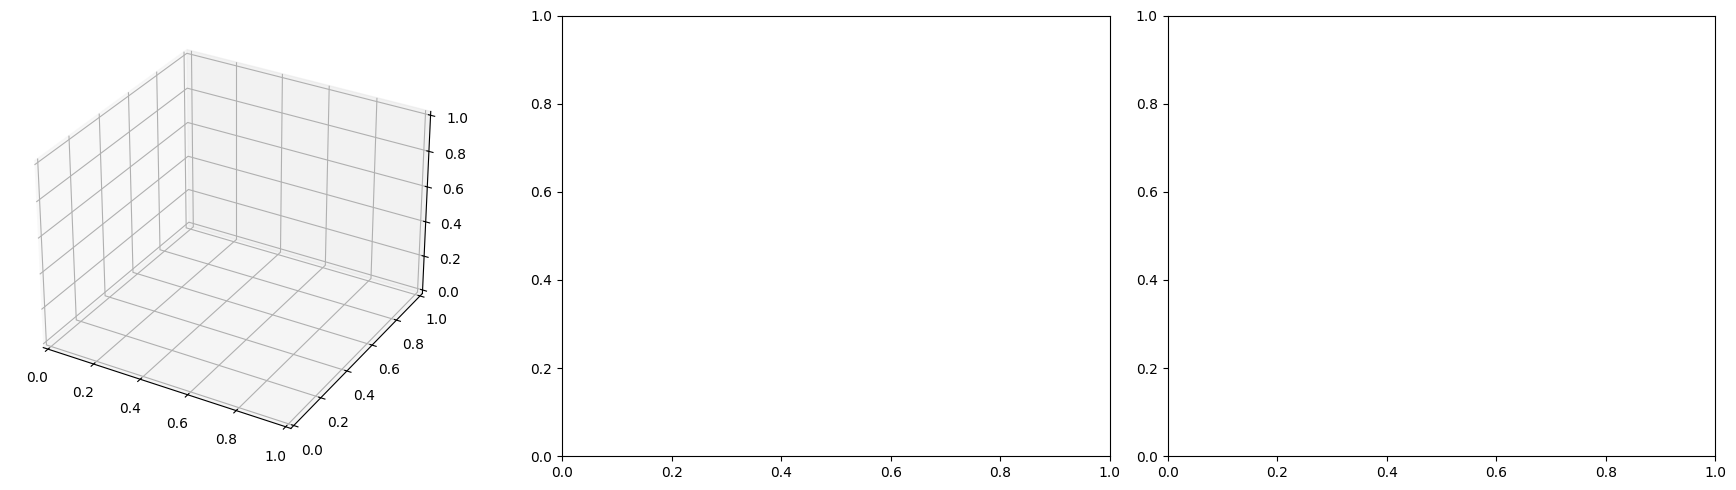

>> Guardando la animación como GIF... Esto puede tardar un par de minutos.
>> ¡GIF guardado con éxito en tu carpeta de trabajo!


In [ ]:
!pip install ripser persim
!pip install ffmpeg
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.integrate import solve_ivp
from ripser import ripser
from persim import plot_diagrams

# --- 1. PARÁMETROS Y CONFIGURACIÓN OPTIMIZADA ---
N = 120          # Reducido para velocidad de cómputo (60 por población)
omega0 = 3.0
K = 0.6
t_span = (0, 15)
num_frames = 30  # Pocos frames con paso grande para carga ultra rápida
t_eval = np.linspace(t_span[0], t_span[1], num_frames)

frecuencias = np.ones(N)
frecuencias[:N//2] = omega0
frecuencias[N//2:] = -omega0

# --- 2. CONDICIONES INICIALES ---
np.random.seed(42)
u = np.random.normal(0, 1, (N, 3))
norm = np.linalg.norm(u, axis=1, keepdims=True)
V0 = (u / norm).flatten()

# --- 3. DINÁMICA DE LOHE ---
def lohe_dynamics(t, v_flat, N, K, frecuencias):
    V = v_flat.reshape((N, 3))
    M = np.mean(V, axis=0)
    dV_dt = np.zeros_like(V)
    for i in range(N):
        w = frecuencias[i]
        rotation = np.array([-w * V[i, 1], w * V[i, 0], 0.0])
        dot_product = np.dot(V[i], M)
        coupling = K * (M - dot_product * V[i])
        dV_dt[i] = rotation + coupling
    return dV_dt.flatten()

# --- 4. PRE-CÓMPUTO DE LA SIMULACIÓN Y TDA ---
print(">> Ejecutando simulación temporal...")
sol = solve_ivp(lohe_dynamics, t_span, V0, t_eval=t_eval, args=(N, K, frecuencias), method='RK45')

print(">> Precalculando Homología Persistente para cada frame (esto ahorrará lag)...")
fases_3d = []
diagramas_tda = []

for f in range(num_frames):
    V_t = sol.y[:, f].reshape((N, 3))
    fases_3d.append(V_t)
    # Calculamos TDA para el estado actual
    rips_t = ripser(V_t, maxdim=2)
    diagramas_tda.append(rips_t['dgms'])

# --- 5. CONFIGURACIÓN DE LA ANIMACIÓN (3 PANELES) ---
fig = plt.figure(figsize=(18, 5))
ax1 = fig.add_subplot(131, projection='3d') # Animación 1: Puntos
ax2 = fig.add_subplot(132)                  # Animación 2: Diagrama
ax3 = fig.add_subplot(133)                  # Animación 3: Barcode

# Esfera de referencia estática
u_mesh, v_mesh = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
x_sphere = np.cos(u_mesh) * np.sin(v_mesh)
y_sphere = np.sin(u_mesh) * np.sin(v_mesh)
z_sphere = np.cos(v_mesh)

colors_tda = ['#d62728', '#2ca02c', '#1f77b4'] # H0, H1, H2
labels_tda = ['$H_0$', '$H_1$', '$H_2$']

def update(frame):
    # --- Limpieza de ejes ---
    ax1.clear()
    ax2.clear()
    ax3.clear()

    t_actual = t_eval[frame]
    V_t = fases_3d[frame]
    dgms = diagramas_tda[frame]

    # --- PANEL 1: MOVIMIENTO DE PUNTOS 3D ---
    ax1.plot_wireframe(x_sphere, y_sphere, z_sphere, color='gray', alpha=0.08, linewidth=0.5)
    ax1.scatter(V_t[:N//2, 0], V_t[:N//2, 1], V_t[:N//2, 2], color='blue', s=25, label=r'Pob. A ($+\omega_0$)')
    ax1.scatter(V_t[N//2:, 0], V_t[N//2:, 1], V_t[N//2:, 2], color='red', s=25, label=r'Pob. B ($-\omega_0$)')
    ax1.set_title(f"Evolución Geométrica ($t = {t_actual:.2f}$)", fontsize=11, fontweight='bold')
    ax1.set_xlim([-1, 1]); ax1.set_ylim([-1, 1]); ax1.set_zlim([-1, 1])
    ax1.legend(loc='upper left', fontsize=8)

    # --- PANEL 2: DIAGRAMA DE PERSISTENCIA ---
    plot_diagrams(dgms, show=False, ax=ax2, legend=True)
    ax2.set_title(f"Diagrama de Persistencia ($t = {t_actual:.2f}$)", fontsize=11, fontweight='bold')
    ax2.set_xlim([-0.1, 2.0]); ax2.set_ylim([-0.1, 2.0])

    # --- PANEL 3: CÓDIGO DE BARRAS (BARCODE) ---
    y_offset = 0
    # Encontrar límite visual dinámico pero estable para las barras infinitas
    max_death = max([np.max(d[:, 1][d[:, 1] != np.inf]) for d in dgms if len(d) > 0 and np.any(d[:, 1] != np.inf)], default=2.0)
    max_limit = max_death * 1.1

    for dim, dim_dgms in enumerate(dgms):
        if len(dim_dgms) == 0: continue
        # Ordenar por persistencia
        sorted_dgms = sorted(dim_dgms, key=lambda x: (x[1] - x[0]), reverse=True)
        for birth, death in sorted_dgms:
            if death == np.inf:
                ax3.plot([birth, max_limit], [y_offset, y_offset], color=colors_tda[dim], lw=2)
                ax3.scatter(max_limit, y_offset, color=colors_tda[dim], marker='>', s=15)
            else:
                ax3.plot([birth, death], [y_offset, y_offset], color=colors_tda[dim], lw=1.5)
            y_offset += 1
        y_offset += 5 # Margen entre dimensiones

    ax3.set_title(f"Código de Barras ($t = {t_actual:.2f}$)", fontsize=11, fontweight='bold')
    ax3.set_xlabel("Filtración ($\epsilon$)")
    ax3.set_xlim([-0.05, max_limit * 1.05])
    ax3.get_yaxis().set_ticks([])
    ax3.grid(True, axis='x', linestyle='--', alpha=0.4)

    # Leyenda manual para el Barcode
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color=colors_tda[i], lw=2) for i in range(len(dgms)) if len(dgms[i]) > 0]
    ax3.legend(custom_lines, [labels_tda[i] for i in range(len(dgms)) if len(dgms[i]) > 0], loc='upper right', fontsize=8)

# --- 6. LANZAR LA ANIMACIÓN ---
# interval=250 da un cuarto de segundo por frame (paso lento y cómodo para analizar)
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=250, repeat=True)

plt.tight_layout()
plt.show()

# NOTA: Si quieres guardar la animación en un archivo ejecutable/video para tu presentación,
# descomenta la siguiente línea (requiere tener instalado 'imagemagick' o 'ffmpeg' en tu sistema):
#ani.save('bifurcacion_topologica_kuramoto.gif', writer='imagemagick', fps=4)

# --- GUARDAR COMO GIF (Añadir al final del script) ---
print(">> Guardando la animación como GIF... Esto puede tardar un par de minutos.")

# fps=4 significa 4 fotogramas por segundo (como tenemos 30 frames, durará unos 7 segundos)
ani.save('bifurcacion_topologica.gif', writer='pillow', fps=4, dpi=100)

print(">> ¡GIF guardado con éxito en tu carpeta de trabajo!")
plt.show()

de esto sale un video muy chulo y mola meter algo de H2


In [ ]:
import os
print("El video se ha guardado en la ruta:", os.getcwd())

El video se ha guardado en la ruta: /content


In [ ]:
import os
print(os.getcwd())

/content


**CODIGO PARA ANALIZAR IMAGENES CON DIAGRAMAS DE PERSISTENCIA**

In [ ]:
pip install numpy matplotlib scikit-image gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 22.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/gudhi/persistence_graphical_tools.py:150: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


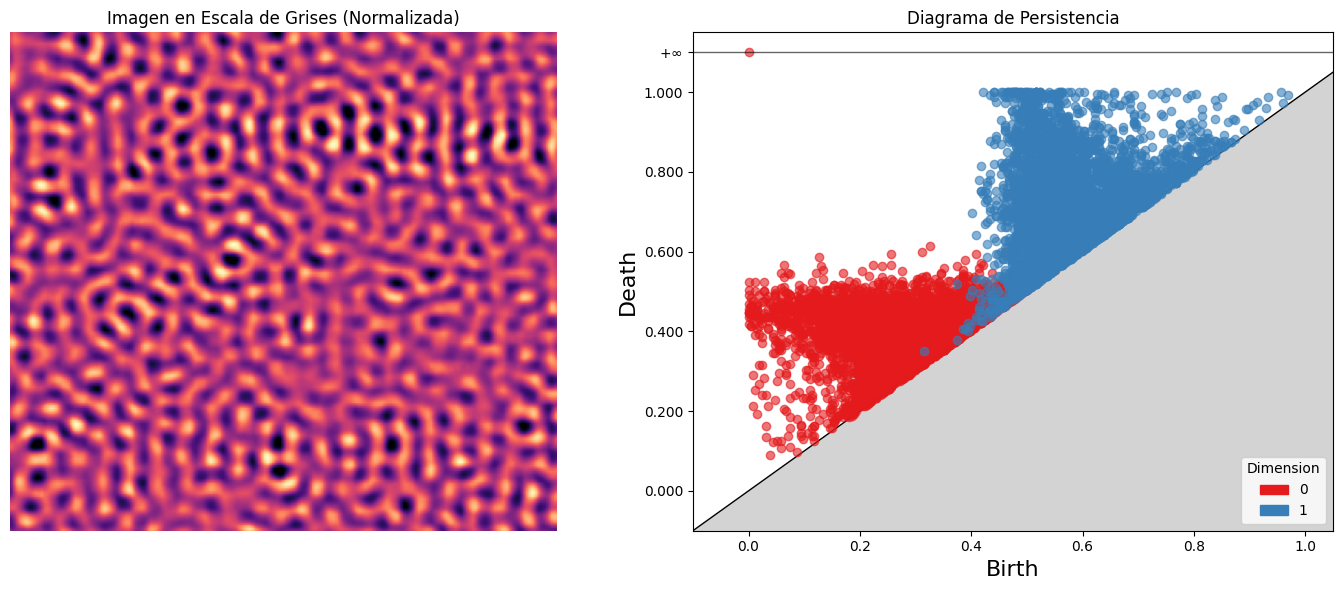

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
import gudhi as gd

def analizar_persistencia_imagen(ruta_imagen):
    # 1. Cargar la imagen
    img_original = io.imread(ruta_imagen)

    # 2. Convertir a escala de grises si es a color
    if len(img_original.shape) == 3:
        # Check if the image has 4 channels (RGBA)
        if img_original.shape[2] == 4:
            # Drop the alpha channel to get an RGB image, then convert to grayscale
            img_gray = color.rgb2gray(img_original[:, :, :3])
        else:
            # Assume it's an RGB image (3 channels), convert directly
            img_gray = color.rgb2gray(img_original)
    else:
        # If not a 3D array, assume it's already grayscale (2D array)
        img_gray = img_original.copy()

    # Normalizar la imagen en el rango [0, 1] para facilitar la interpretación
    img_gray = (img_gray - np.min(img_gray)) / (np.max(img_gray) - np.min(img_gray))

    # Invertir la imagen si queremos una filtración por SUPERniveles (picos de brillo primero).
    # GUDHI por defecto hace filtración por SUBniveles (valores bajos primero).
    # Al hacer (1 - img), los píxeles más brillantes se vuelven 0 (nacen primero).
    img_gudhi = 1.0 - img_gray

    # 3. Construir el Complejo Cúbico (Cubical Complex)
    # Esto interpreta la matriz de píxeles como un mapa de alturas topológico
    cubical_complex = gd.CubicalComplex(
        dimensions=img_gudhi.shape,
        top_dimensional_cells=img_gudhi.flatten()
    )

    # 4. Calcular la homología persistente
    cubical_complex.compute_persistence()

    # 5. Visualización de Resultados
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Mostrar imagen original en escala de grises
    axes[0].imshow(img_gray, cmap='magma')
    axes[0].set_title("Imagen en Escala de Grises (Normalizada)")
    axes[0].axis('off')

    # Graficar el diagrama de persistencia
    gd.plot_persistence_diagram(cubical_complex.persistence(), axes=axes[1])
    axes[1].set_title("Diagrama de Persistencia")

    plt.tight_layout()
    plt.show()

# --- Ejecución del script ---
# Reemplaza 'tu_imagen.png' por la ruta del fragmento que quieras analizar
analizar_persistencia_imagen('grafeno.png')

Preprocesamiento y Normalización: El algoritmo transforma la imagen a escala de grises, gestionando correctamente canales de transparencia (RGBA) si existieran. Posteriormente, escala los valores de los píxeles al rango $[0, 1]$.

Inversión de Contraste (Filtración por Superniveles): Dado que la librería GUDHI realiza por defecto una filtración por subniveles (los valores más bajos nacen primero), el código invierte la imagen (1.0 - img_gray). De esta forma, los píxeles originalmente más brillantes (picos de intensidad) se convierten en valores cercanos a 0, permitiendo que las estructuras de alto brillo "nazcan" primero en el análisis.

Construcción del **Complejo Cúbico**: A diferencia de las nubes de puntos (donde se usan complejos de Vietoris-Rips), aquí se utiliza un Complejo Cúbico . Los píxeles se tratan como píldoras o "celdas" estructuradas en una rejilla regular, ideal para datos basados en matrices. **tendría que incluir este complejo en el fundamento teórico, por ahora uso VR y alpha, creo que comparar las aplicaciones de cada complejo podría ser interesante de cara al trabajo**

Cálculo de la Persistencia: Se barren secuencialmente los niveles de gris para identificar el nacimiento y muerte de componentes conexas ($H_0$, como picos aislados de brillo) y bucles o agujeros ($H_1$, como valles o cuencas oscuras rodeadas de brillo).
**
El diagrama de persistencia obtenido para la imagen analizada (grafeno.png) **no muestra estructuras claras ni una separación evidente entre el ruido y las características persistentes**.

Esto no es un falla del código sino que la imagen elegido puede no haber sido la más optima para este análisis. **se puede intentar aplicar a otras imagen como las que le enseñé del tratamiento de un material con laser**


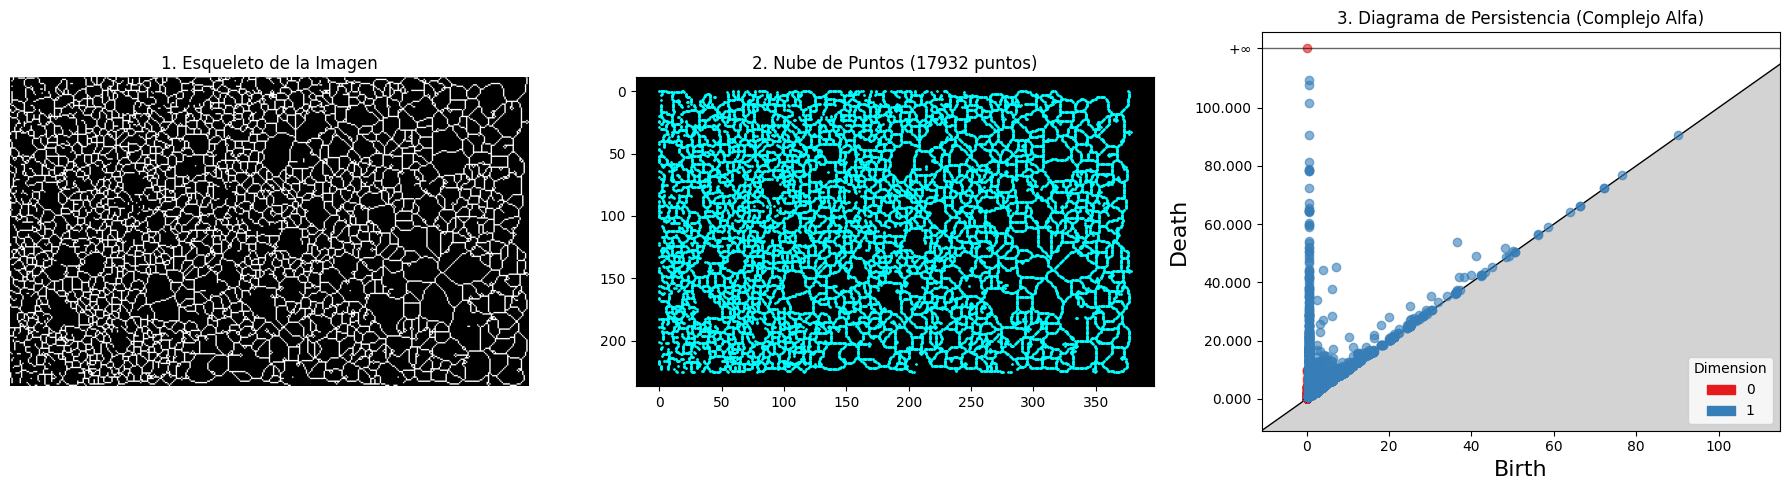

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, morphology
import gudhi as gd

def analizar_nube_puntos_imagen(ruta_imagen):
    # 1. Cargar la imagen y convertir a escala de grises
    img_original = io.imread(ruta_imagen)
    if len(img_original.shape) == 3:
        # Check if the image has 4 channels (RGBA)
        if img_original.shape[2] == 4:
            # Drop the alpha channel to get an RGB image, then convert to grayscale
            img_gray = color.rgb2gray(img_original[:, :, :3])
        else:
            # Assume it's an RGB image (3 channels), convert directly
            img_gray = color.rgb2gray(img_original)
    else:
        # If not a 3D array, assume it's already grayscale (2D array)
        img_gray = img_original.copy()

    # 2. Binarización (Filtro de Otsu)
    # Encuentra automáticamente el mejor umbral para separar las uniones brillantes del fondo oscuro
    umbral = filters.threshold_otsu(img_gray)
    img_binaria = img_gray > umbral

    # 3. Esqueletización
    # Adelgaza las líneas gruesas hasta dejarlas de 1 solo píxel de ancho
    img_esqueleto = morphology.skeletonize(img_binaria)

    # 4. Extraer la Nube de Puntos
    # np.argwhere devuelve las coordenadas en formato (Fila, Columna) -> (Y, X)
    puntos_y_x = np.argwhere(img_esqueleto)

    # Intercambiamos las columnas para tener coordenadas cartesianas estándar (X, Y)
    nube_puntos = np.column_stack((puntos_y_x[:, 1], puntos_y_x[:, 0]))

    # 5. Construir el Complejo Alfa (Equivalente optimizado de Rips para 2D)
    alpha_complex = gd.AlphaComplex(points=nube_puntos)
    simplex_tree = alpha_complex.create_simplex_tree()

    # 6. Calcular la Homología Persistente
    simplex_tree.compute_persistence()

    # 7. Visualización completa del proceso
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # A. Imagen binarizada y esqueletizada
    axes[0].imshow(img_esqueleto, cmap='gray')
    axes[0].set_title("1. Esqueleto de la Imagen")
    axes[0].axis('off')

    # B. Nube de Puntos extraída
    axes[1].scatter(nube_puntos[:, 0], nube_puntos[:, 1], s=1, c='cyan')
    axes[1].set_title(f"2. Nube de Puntos ({len(nube_puntos)} puntos)")
    axes[1].invert_yaxis() # Invertir el eje Y para que coincida con la imagen original
    axes[1].set_aspect('equal')
    axes[1].set_facecolor('black')

    # C. Diagrama de Persistencia
    gd.plot_persistence_diagram(simplex_tree.persistence(), axes=axes[2])
    axes[2].set_title("3. Diagrama de Persistencia (Complejo Alfa)")

    plt.tight_layout()
    plt.show()

# --- Ejecución del script ---
# Recuerda cambiar la ruta por la correcta en tu entorno de Colab
analizar_nube_puntos_imagen('ns.png')

Binarización Inteligente (Umbral de Otsu): El algoritmo utiliza el método de Otsu para calcular automáticamente el umbral óptimo que separa los elementos de interés (filamentos, redes, paredes) del fondo negro, eliminando variaciones menores de iluminación. **habría que explicar la teoría detrás del método, es bastante sencilla**

Esqueletización Morfológica: Este es un paso crítico. Consiste en adelgazar las estructuras binarias hasta que tengan el grosor de un solo píxel, preservando la topología original (no se crean ni se destruyen agujeros). Esto elimina el "ruido de grosor" y se concentra únicamente en la conectividad del sistema.

Extracción de la Nube de Puntos: Las coordenadas espaciales $(x, y)$ de los píxeles que componen el esqueleto se extraen para formar una nube de puntos discreta en $\mathbb{R}^2$.

Finalmente se construyen los complejos alpha que nos dan más velocidad computacional que VR.

 **MUCHAS FRECUENCIAS DISTINTAS FISICA ESTADISTICA**

In [ ]:
!pip install ripser persim

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 843.4/843.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.1 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=7cf7f3811a6ed7e10f791a8496f3d5cbce346c75ec826362e4ebc5f4bbc2ab9e
  Stored in directory: /root/.cache/pip/wheels/2a/fd/fe/f4b8fd82894e1d9e04040ef41dc5ae6eb7a8e9b0ef5a9402fe
Successfully built hopcroftkarp


>> Simulando el modelo de Heisenberg Activo (Gaussian disorder)...
>> Simulación completada en 0.06 segundos.

>> Calculando homología persistente paralela para los 3 estados...
>> TDA completado en 13.91 segundos.

>> Mostrando resultados. La simulación está completa.


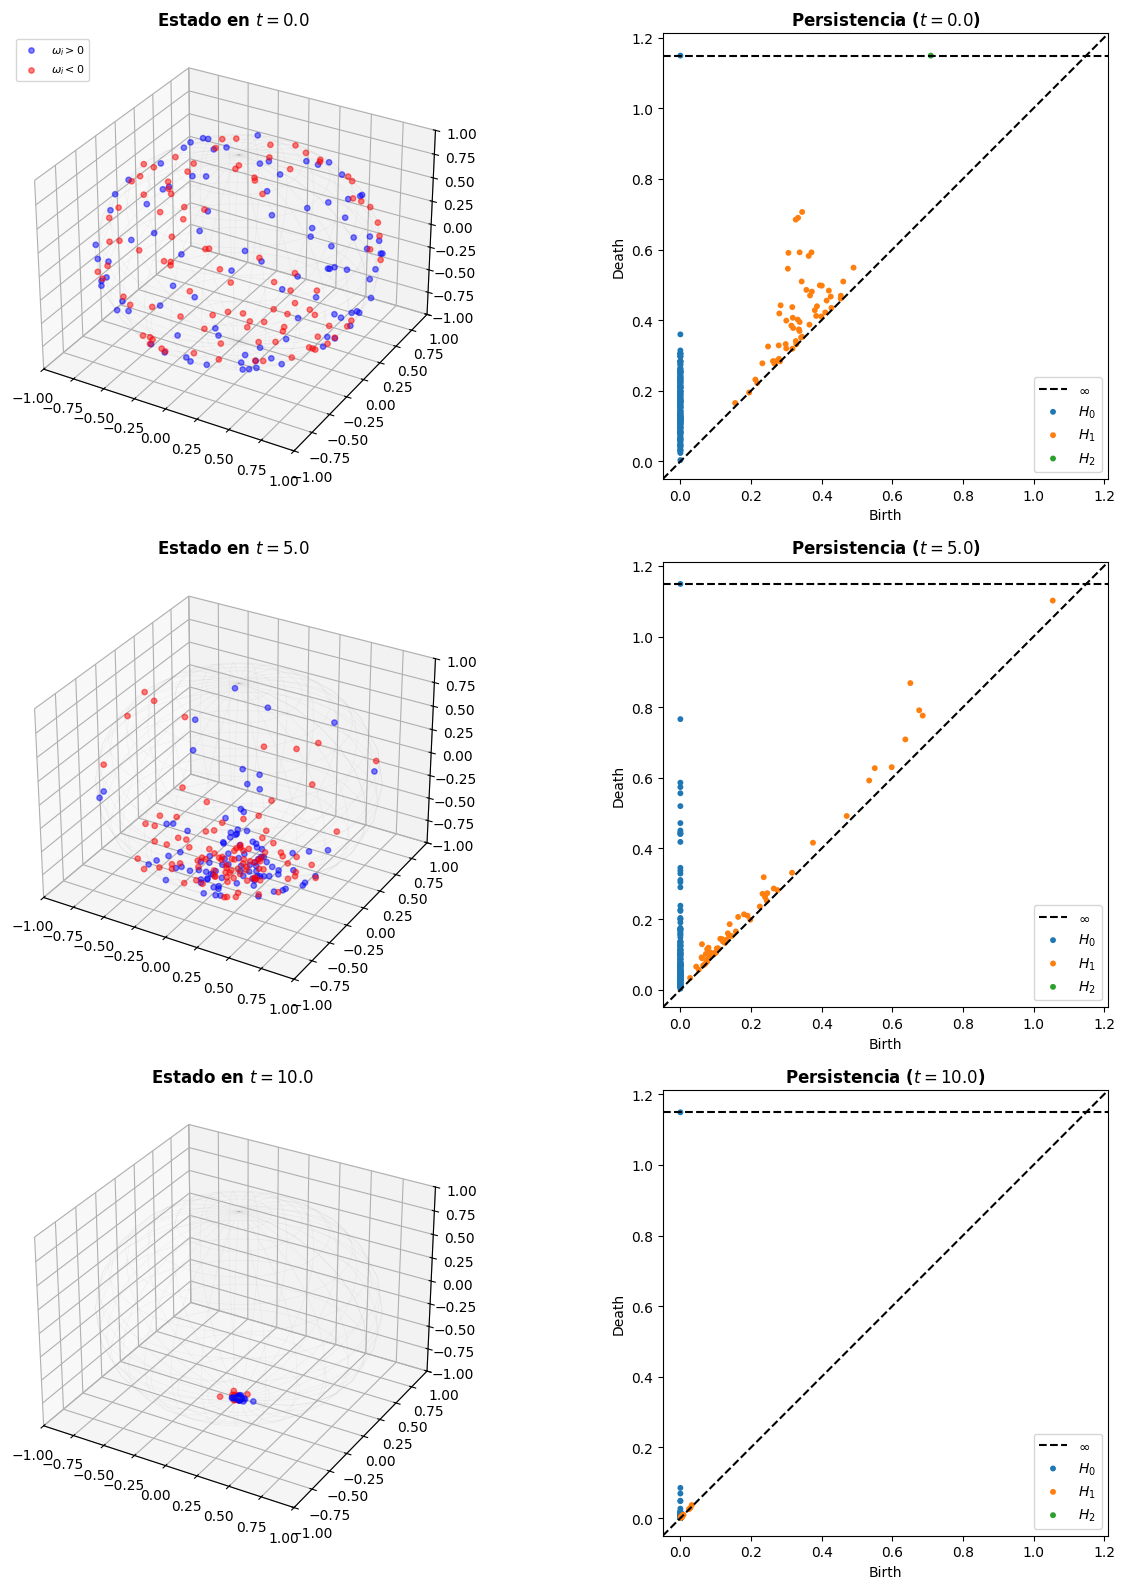

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ripser import ripser
from persim import plot_diagrams
from joblib import Parallel, delayed
import time

# =====================================================================
# --- 1. CONFIGURACIÓN DEL SISTEMA ---
# =====================================================================
np.random.seed(42) # Semilla fija para reproducibilidad
N = 200            # Número de espines (N=200 es bueno para H2 en S^2)
K = 0.8            # Acoplamiento de alineación (Heisenberg ferromagnético)
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], 400)

# DEFINICIÓN DEL DESORDEN ACTIVO (Uniform Frequencies)
# Distribución uniforme entre -3 y 3.
omega_distribucion = np.random.uniform(low=-3.0, high=3.0, size=N)

# Definimos los ejes de rotación global (Eje Z para simplificar la física)
axis = np.array([0, 0, 1.0])

# =====================================================================
# --- 2. CONDICIONES INICIALES (Distribución Uniforme en S^2) ---
# =====================================================================
u = np.random.normal(0, 1, (N, 3))
norm = np.linalg.norm(u, axis=1, keepdims=True)
V0_plane = (u / norm) # Estado inicial: Desorden total
V0_flat = V0_plane.flatten()

V_inicial_Nx3 = V0_plane.copy() # Guardamos para TDA

# =====================================================================
# --- 3. DINÁMICA DE HEISENBERG ACTIVO (Vectorizada) ---
# =====================================================================
def active_heisenberg_dynamics(t, v_flat, N, K, frequencies, axis):
    """
    Simula espines de Heisenberg acoplados globalmente con frecuencias de
    rotación intrínsecas individuales extraídas de una distribución Gaussiana.
    """
    V = v_flat.reshape((N, 3))
    M = np.mean(V, axis=0) # Campo Medio / Centro de Masa

    # 1. Rotación Intrínseca (Active Disorder)
    # rot_x = -w * y, rot_y = w * x, rot_z = 0 (Eje Z)
    rot_x = -frequencies * V[:, 1]
    rot_y = frequencies * V[:, 0]
    rotation = np.column_stack((rot_x, rot_y, np.zeros_like(rot_x)))

    # 2. Acoplamiento de Alineación (ferromagnético)
    # dot_products = x_i \cdot M
    dot_products = V @ M
    coupling = K * (M - dot_products[:, np.newaxis] * V)

    dV_dt = rotation + coupling
    return dV_dt.flatten()

# =====================================================================
# --- 4. EJECUCIÓN DE LA SIMULACIÓN ---
# =====================================================================
print(">> Simulando el modelo de Heisenberg Activo (Gaussian disorder)...")
t_start_sim = time.time()
sol = solve_ivp(active_heisenberg_dynamics, t_span, V0_flat, t_eval=t_eval,
                args=(N, K, omega_distribucion, axis), method='RK45')
print(f">> Simulación completada en {time.time() - t_start_sim:.2f} segundos.")

# Extraer estados clave para TDA
num_frames_total = len(t_eval) # Define num_frames_total
mid_time_idx = num_frames_total // 2
V_intermedio_Nx3 = sol.y[:, mid_time_idx].reshape((N, 3))
V_final_Nx3 = sol.y[:, -1].reshape((N, 3))

# =====================================================================
# --- 5. ANÁLISIS TOPOLÓGICO PARALELIZADO Y ESCALADO ---
# =====================================================================
def calcular_tda_acotado(V_estado):
    # thresh=1.5 es crucial para H2 en S^2 con N=200
    rips_res = ripser(V_estado, maxdim=2, thresh=1.5)
    return rips_res['dgms']

print("\n>> Calculando homología persistente paralela para los 3 estados...")
t_start_tda = time.time()
diamas = Parallel(n_jobs=-1)(
    delayed(calcular_tda_acotado)(estado)
    for estado in [V_inicial_Nx3, V_intermedio_Nx3, V_final_Nx3]
)
dgms_inicial, dgms_intermedio, dgms_final = diamas
print(f">> TDA completado en {time.time() - t_start_tda:.2f} segundos.")

# CÁLCULO DEL RANGO GLOBAL DE EJES PARA TDA (Crucial para comparación visual)
def get_max_death_finite(dgms):
    max_d = 0.0
    for dgm in dgms:
        if len(dgm) > 0:
            finite_deaths = dgm[dgm[:, 1] != np.inf][:, 1]
            if len(finite_deaths) > 0: max_d = max(max_d, np.max(finite_deaths))
    return max_d

global_death_max = max(get_max_death_finite(d) for d in diamas)
rango_global = [-0.05, global_death_max * 1.1, -0.05, global_death_max * 1.1]

# =====================================================================
# --- 6. VISUALIZACIÓN EN CUADRÍCULA 3X2 (Heisenberg Activo) ---
# =====================================================================
fig = plt.figure(figsize=(14, 16))

# Malla de referencia de la esfera unitaria
u_m, v_m = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
x_s = np.cos(u_m) * np.sin(v_m); y_s = np.sin(u_m) * np.sin(v_m); z_s = np.cos(v_m)

pob_a_idx = np.where(omega_distribucion > 0)[0]
pob_b_idx = np.where(omega_distribucion <= 0)[0]

def plot_state_row(row, t_curr, V_data, dgms_data, is_inicial=False):
    # Columna 1: Geometría 3D
    ax1 = fig.add_subplot(320 + (row*2 + 1), projection='3d')
    ax1.plot_wireframe(x_s, y_s, z_s, color='gray', alpha=0.08, linewidth=0.5)

    # Dividimos visualmente por frecuencias positivas/negativas solo como guia visual
    ax1.scatter(V_data[pob_a_idx, 0], V_data[pob_a_idx, 1], V_data[pob_a_idx, 2], color='blue', s=15, alpha=0.5, label=r'$\omega_i > 0$')
    ax1.scatter(V_data[pob_b_idx, 0], V_data[pob_b_idx, 1], V_data[pob_b_idx, 2], color='red', s=15, alpha=0.5, label=r'$\omega_i < 0$')
    ax1.set_title(f"Estado en $t={t_curr:.1f}$", fontweight='bold')
    if is_inicial: ax1.legend(loc='upper left', fontsize=8)
    ax1.set_xlim([-1, 1]); ax1.set_ylim([-1, 1]); ax1.set_zlim([-1, 1])

    # Columna 2: Diagrama de Persistencia Escalado
    ax2 = fig.add_subplot(320 + (row*2 + 2))
    # size=15 y color map optimizado para TFG (legend=True)
    plot_diagrams(dgms_data, show=False, ax=ax2, legend=True, xy_range=rango_global, size=18)
    ax2.set_title(f"Persistencia ($t={t_curr:.1f}$)", fontweight='bold')

# Fila 1: T=0
plot_state_row(0, sol.t[0], V_inicial_Nx3, dgms_inicial, is_inicial=True)
# Fila 2: T_mid
plot_state_row(1, sol.t[mid_time_idx], V_intermedio_Nx3, dgms_intermedio)
# Fila 3: T_final
plot_state_row(2, sol.t[-1], V_final_Nx3, dgms_final)

plt.tight_layout()
print("\n>> Mostrando resultados. La simulación está completa.")
plt.show()

Este código es una modificación del que hay más arriba, en vez de dividir la población en omega \pm 3 se distribuye de forma uniforme entre esos mismos valores. El resultado es que converge antes porque los puntos cuyo omega esta cerca de cero convergen antes y "tiran" del resto de puntos.

Aunque topológicamente no aporta nada nuevo, esta simulación se ajusta más a una modelización física y **se le puede encontrar una aplicación a la física estadística.**

**CODIGO QUE CALCULA EL K CRITICO**

>> Iniciando el barrido de K en paralelo...
>> Analizando 25 valores de acoplamiento...


<>:110: SyntaxWarning: invalid escape sequence '\m'
<>:110: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1855/2655735876.py:110: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Estudio del Punto Crítico en $\mathbb{S}^1$ mediante Homología Persistente ($H_1$)", fontsize=12, fontweight='bold')


>> Estudio completado en 25.11 segundos.


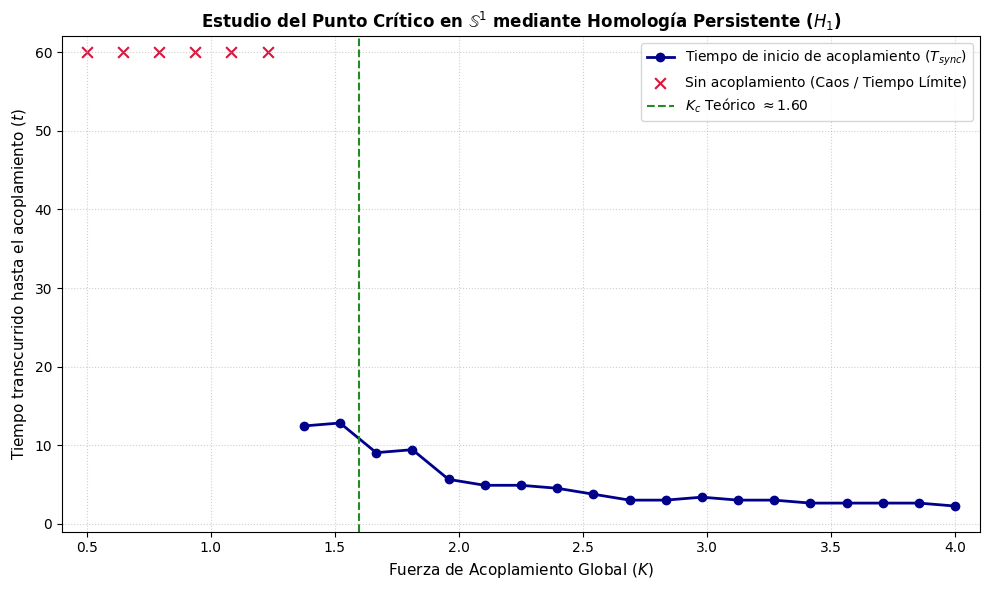

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ripser import ripser
from joblib import Parallel, delayed
import time

# =====================================================================
# --- 1. PARÁMETROS GLOBALES DEL EXPERIMENTO ---
# =====================================================================
np.random.seed(42)
N = 100                  # Número de osciladores en S^1 (suficiente y rápido)
t_span = (0, 60)         # Tiempo máximo de observación
t_eval = np.linspace(t_span[0], t_span[1], 160) # 160 pasos temporales

# Frecuencias naturales extraídas de una Gaussiana (Desorden)
# Para sigma=1.0, el K crítico teórico de Kuramoto es ~1.59
sigma = 1.0
frecuencias = np.random.normal(loc=0.0, scale=sigma, size=N)

# Condiciones iniciales: distribución uniforme aleatoria en el círculo [-pi, pi]
theta0 = np.random.uniform(-np.pi, np.pi, size=N)

# Rango de fuerzas de acoplamiento K a evaluar
K_valores = np.linspace(0.5, 4.0, 25)

# =====================================================================
# --- 2. FUNCIÓN DE SIMULACIÓN Y DETECCIÓN TOPOLÓGICA POR ENTORNO K ---
# =====================================================================
def evaluar_tiempo_acoplamiento(K, theta0, frecuencias, t_span, t_eval, N):
    """
    Simula el modelo de Kuramoto para un K dado y devuelve el primer
    instante de tiempo donde el agujero H1 colapsa (inicio de sincronización).
    """
    # Dinámica de Kuramoto en S^1 completamente vectorizada (Matriz N x N)
    def kuramoto_s1_dynamics(t, theta):
        # Diferencia de fases matricial: theta_j - theta_i
        fases_relativas = theta[None, :] - theta[:, None]
        dtheta_dt = frecuencias + (K / N) * np.sum(np.sin(fases_relativas), axis=1)
        return dtheta_dt

    # Resolver la ecuación diferencial
    sol = solve_ivp(kuramoto_s1_dynamics, t_span, theta0, t_eval=t_eval, method='RK45')

    # Analizar la topología cuadro por cuadro a lo largo del tiempo
    for idx, t in enumerate(sol.t):
        theta_t = sol.y[:, idx]

        # Mapeo geométrico intrínseco de fases a coordenadas cartesianas R^2
        X = np.column_stack((np.cos(theta_t), np.sin(theta_t)))

        # Calcular Homología Persistente solo hasta dimensión 1 (H1)
        dgms = ripser(X, maxdim=1)['dgms']
        h1 = dgms[1]

        # Calcular la persistencia máxima del agujero central de S^1
        if len(h1) == 0:
            max_persistencia = 0.0
        else:
            max_persistencia = np.max(h1[:, 1] - h1[:, 0])

        # CRITERIO TDA: Si la persistencia del agujero cae por debajo de 0.6,
        # el círculo se ha roto debido a la nucleación de un clúster (Sincronización).
        if max_persistencia < 0.6:
            return t # Retornamos el tiempo exacto de acoplamiento

    return np.nan # Si termina el tiempo y sigue desordenado, no hubo acoplamiento

# =====================================================================
# --- 3. EJECUCIÓN MULTIHILO EN PARALELO ---
# =====================================================================
print(">> Iniciando el barrido de K en paralelo...")
print(f">> Analizando {len(K_valores)} valores de acoplamiento...")
t_start = time.time()

# Paralelización nativa sobre todos los núcleos de tu procesador
tiempos_acoplamiento = Parallel(n_jobs=-1)(
    delayed(evaluar_tiempo_acoplamiento)(K, theta0, frecuencias, t_span, t_eval, N)
    for K in K_valores
)

print(f">> Estudio completado en {time.time() - t_start:.2f} segundos.")

# =====================================================================
# --- 4. PROCESAMIENTO DE DATOS Y GRAFICACIÓN ---
# =====================================================================
tiempos_acoplamiento = np.array(tiempos_acoplamiento)

# Separamos los valores que lograron acoplamiento de los que permanecieron caóticos
mascara_sincroniza = ~np.isnan(tiempos_acoplamiento)
mascara_no_sincroniza = np.isnan(tiempos_acoplamiento)

plt.figure(figsize=(10, 6))

# Dibujar la curva de tiempo de acoplamiento
plt.plot(K_valores[mascara_sincroniza], tiempos_acoplamiento[mascara_sincroniza],
         'o-', color='darkblue', linewidth=2, label='Tiempo de inicio de acoplamiento ($T_{sync}$)')

# Representar los puntos que nunca acoplaron (debajo del punto crítico)
if np.any(mascara_no_sincroniza):
    plt.scatter(K_valores[mascara_no_sincroniza], [t_span[1]] * np.sum(mascara_no_sincroniza),
                color='crimson', marker='x', s=60, label='Sin acoplamiento (Caos / Tiempo Límite)')

# Línea vertical para el punto crítico teórico K_c = 2 * sqrt(2/pi)
K_c_teorico = 2 * np.sqrt(2 / np.pi)
plt.axvline(x=K_c_teorico, color='forestgreen', linestyle='--', linewidth=1.5,
            label=f'$K_c$ Teórico $\\approx {K_c_teorico:.2f}$')

# Formato estético para publicación de TFG
plt.title("Estudio del Punto Crítico en $\mathbb{S}^1$ mediante Homología Persistente ($H_1$)", fontsize=12, fontweight='bold')
plt.xlabel("Fuerza de Acoplamiento Global ($K$)", fontsize=11)
plt.ylabel("Tiempo transcurrido hasta el acoplamiento ($t$)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim([K_valores[0] - 0.1, K_valores[-1] + 0.1])
plt.ylim([-1, t_span[1] + 2])
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

Esta simulación se centra en el cálculo de la K crítica del modelo de Kuramoto. Lo que hace es tomar el ejemplo más sencillo que teniamos al principio, osciladores en S1. Calcula el tiempo de acoplamiento para distintos valores de K y determina si hay o no acoplamiento valiendose de la persistencia de H1. **Puede servir para completar algo más el primer ejemplo e ilustrar la dependencia de K en el modelo de Kuramoto**

A continuación desarrollo la sugerencia de tomar varias semillas y representar media y desv tip

>> Iniciando barrido: 25 valores de K x 10 semillas.
>> Tareas totales en cola: 250. Esto tomará un tiempo...
>> Estudio completado en 81.73 segundos.


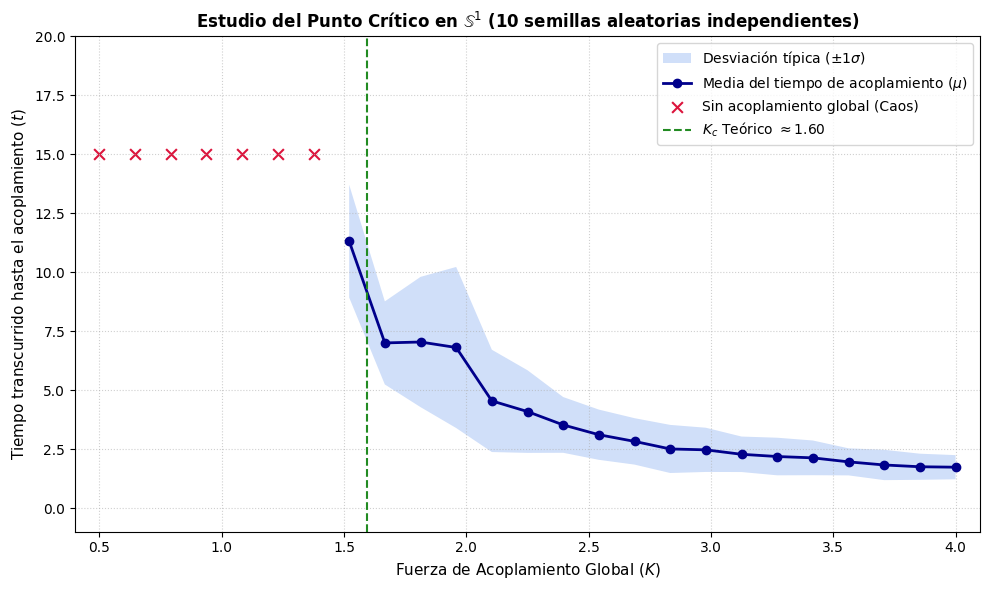

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ripser import ripser
from joblib import Parallel, delayed
import time
import warnings

# =====================================================================
# --- 1. PARÁMETROS GLOBALES DEL EXPERIMENTO ---
# =====================================================================
num_semillas = 10        # Número de realizaciones independientes
N = 100                  # Número de osciladores en S^1 (coincide con el texto del TFG)
t_span = (0, 15)         # Tiempo máximo de observación
t_eval = np.linspace(t_span[0], t_span[1], 160)

# Frecuencias naturales extraídas de una Gaussiana
sigma = 1.0
K_valores = np.linspace(0.5, 4.0, 25)

# Fracción de la persistencia INICIAL por debajo de la cual consideramos
# que la clase dominante de H1 (el "anillo") ha dejado de ser significativa.
# Es el único parámetro libre del criterio topológico.
FRACCION_COLAPSO = 0.5

# =====================================================================
# --- 2. FUNCIÓN DE SIMULACIÓN Y DETECCIÓN ---
# =====================================================================
def evaluar_tiempo_acoplamiento(K, theta0, frecuencias, t_span, t_eval, N):
    """
    Simula el modelo de Kuramoto en S^1 y detecta la rotura del anillo
    mediante el COLAPSO DE LA PERSISTENCIA del generador dominante de H1.

    Criterio topológico
    -------------------
    La persistencia de una clase es (muerte - nacimiento), es decir, su
    distancia a la diagonal del diagrama de persistencia: la medida canónica
    de significatividad topológica. El anillo se considera roto en el primer
    instante en el que la persistencia máxima de H1 cae por debajo de una
    fracción de su valor en t=0.

    Equivalencia con la distancia bottleneck
    ----------------------------------------
    Para un diagrama D, la distancia bottleneck al diagrama vacío (todos los
    puntos emparejados con la diagonal) es d_B(D, vacío) = (1/2) * max(muerte-nac).
    Por tanto, este criterio equivale a exigir d_B(D_actual, vacío) < umbral/2.
    """
    def kuramoto_s1_dynamics(t, theta):
        # Optimización por Campo Medio O(N) para acelerar la ejecución
        Z = np.mean(np.exp(1j * theta))
        return frecuencias + K * np.imag(Z * np.exp(-1j * theta))

    sol = solve_ivp(kuramoto_s1_dynamics, t_span, theta0,
                    t_eval=t_eval, method='RK45')

    # --- PASO 1: BASELINE DE PERSISTENCIA EN t=0 ---
    theta_0 = sol.y[:, 0]
    X_0 = np.column_stack((np.cos(theta_0), np.sin(theta_0)))
    h1_0 = ripser(X_0, maxdim=1)['dgms'][1]

    if len(h1_0) == 0:
        return np.nan  # Si no hay círculo inicial, la muestra no es válida

    # Persistencia del ciclo dominante en el estado desordenado.
    # Para una distribución uniforme sobre el círculo unidad vale ~ sqrt(3) ~ 1.73
    persistencia_inicial = np.max(h1_0[:, 1] - h1_0[:, 0])

    # Umbral RELATIVO al estado inicial -> robusto a la escala y a la realización
    umbral_persistencia = FRACCION_COLAPSO * persistencia_inicial

    # --- PASO 2: BARRIDO TEMPORAL ---
    # Evaluamos cada 2 pasos para equilibrar precisión y velocidad con Ripser
    for idx in range(0, len(sol.t), 2):
        t = sol.t[idx]
        theta_t = sol.y[:, idx]

        X = np.column_stack((np.cos(theta_t), np.sin(theta_t)))
        h1 = ripser(X, maxdim=1)['dgms'][1]

        if len(h1) == 0:
            # Ripser ya no encuentra ningún ciclo: el anillo ha colapsado por completo
            return t

        # Persistencia (distancia a la diagonal) del ciclo dominante en este instante
        persistencia_max = np.max(h1[:, 1] - h1[:, 0])

        # El generador dominante de H1 ha dejado de ser topológicamente significativo
        if persistencia_max < umbral_persistencia:
            return t

    return np.nan

# Wrapper para poder paralelizar por semilla y por K simultáneamente
def simular_instancia(K, semilla):
    # Fijar semilla local para esta instancia exacta
    np.random.seed(semilla)
    frecuencias = np.random.normal(loc=0.0, scale=sigma, size=N)
    theta0 = np.random.uniform(-np.pi, np.pi, size=N)
    return evaluar_tiempo_acoplamiento(K, theta0, frecuencias, t_span, t_eval, N)

# =====================================================================
# --- 3. EJECUCIÓN MULTIHILO EN PARALELO ---
# =====================================================================
total_tareas = len(K_valores) * num_semillas
print(f">> Iniciando barrido: {len(K_valores)} valores de K x {num_semillas} semillas.")
print(f">> Tareas totales en cola: {total_tareas}. Esto tomará un tiempo...")
t_start = time.time()

# Creamos una lista con todas las combinaciones posibles de (K, semilla)
tareas = [(K, s) for K in K_valores for s in range(num_semillas)]

# Ejecutamos todas las tareas en paralelo
resultados_planos = Parallel(n_jobs=-1)(
    delayed(simular_instancia)(K, s) for K, s in tareas
)

print(f">> Estudio completado en {time.time() - t_start:.2f} segundos.")

# =====================================================================
# --- 4. PROCESAMIENTO DE DATOS ESTADÍSTICOS ---
# =====================================================================
# Redimensionar los resultados: Filas = K_valores, Columnas = semillas
matriz_tiempos = np.array(resultados_planos).reshape(len(K_valores), num_semillas)

# Ignoramos los RuntimeWarnings puntuales de numpy si alguna fila completa es NaN
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    media_t = np.nanmean(matriz_tiempos, axis=1)
    std_t = np.nanstd(matriz_tiempos, axis=1)

# =====================================================================
# --- 5. GRAFICACIÓN CON MEDIA Y DESVIACIÓN TÍPICA ---
# =====================================================================
plt.figure(figsize=(10, 6))

# Máscara para aquellos valores de K donde AL MENOS una semilla logró sincronizar
mascara_valida = ~np.isnan(media_t)

# 1. Dibujar el área de desviación estándar (sombreado)
plt.fill_between(K_valores[mascara_valida],
                 media_t[mascara_valida] - std_t[mascara_valida],
                 media_t[mascara_valida] + std_t[mascara_valida],
                 color='cornflowerblue', alpha=0.3, edgecolor='none',
                 label='Desviación típica ($\\pm 1\\sigma$)')

# 2. Dibujar la curva principal (Media)
plt.plot(K_valores[mascara_valida], media_t[mascara_valida],
         'o-', color='darkblue', linewidth=2, label='Media del tiempo de acoplamiento ($\\mu$)')

# 3. Representar las zonas de caos absoluto (donde TODAS las semillas fallaron)
mascara_invalida = np.isnan(media_t)
if np.any(mascara_invalida):
    plt.scatter(K_valores[mascara_invalida], [t_span[1]] * np.sum(mascara_invalida),
                color='crimson', marker='x', s=60, label='Sin acoplamiento global (Caos)')

# Línea vertical teórica
K_c_teorico = 2 * np.sqrt(2 / np.pi)
plt.axvline(x=K_c_teorico, color='forestgreen', linestyle='--', linewidth=1.5,
            label=f'$K_c$ Teórico $\\approx {K_c_teorico:.2f}$')

# Formato estético
plt.title(f"Estudio del Punto Crítico en $\\mathbb{{S}}^1$ ({num_semillas} semillas aleatorias independientes)", fontsize=12, fontweight='bold')
plt.xlabel("Fuerza de Acoplamiento Global ($K$)", fontsize=11)
plt.ylabel("Tiempo transcurrido hasta el acoplamiento ($t$)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim([K_valores[0] - 0.1, K_valores[-1] + 0.1])
plt.ylim([-1, t_span[1] + 5])
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

**Puntos kuramoto**

Datos cargados con éxito. Filas detectadas: 965365


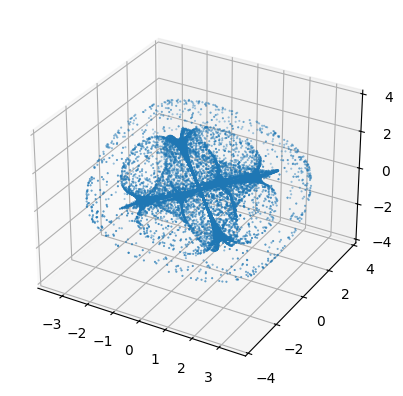

In [ ]:
import scipy.io as sio
import matplotlib.pyplot as plt

# 1. Cargar el archivo .mat
datos = sio.loadmat('puntosTFG.mat')

# 2. Extraer los vectores x, y, z
x = datos['x']
y = datos['y']
z = datos['z']

print(f"Datos cargados con éxito. Filas detectadas: {len(x)}")

# 3. Opcional: Hacer un gráfico rápido en 3D para ver qué son
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(x[::20], y[::20], z[::20], marker='.', s=1) # Grafica 1 de cada 2 puntos para que no vaya lento
plt.show()

#he llegado a probar con graficar la mitad de los puntos, tarda menos de 30s pero se ve muy emborronado, pueden hacerse los puntos mas pequeños pero me
#resulta interesante la idea de trabajar solo con algunos de los puntos.


Simplemente se han representado una fracción de los puntos de la base de datos que me mandó. Son demasiados para representarlos todos sin que sea confuso.

In [ ]:
!pip install ripser matplotlib scipy persim gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 30.9 MB/s eta 0:00:00


In [ ]:
!pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 29.5 MB/s eta 0:00:00


**Además lo hago seleccionando los datos con  farthest_point_sampling **

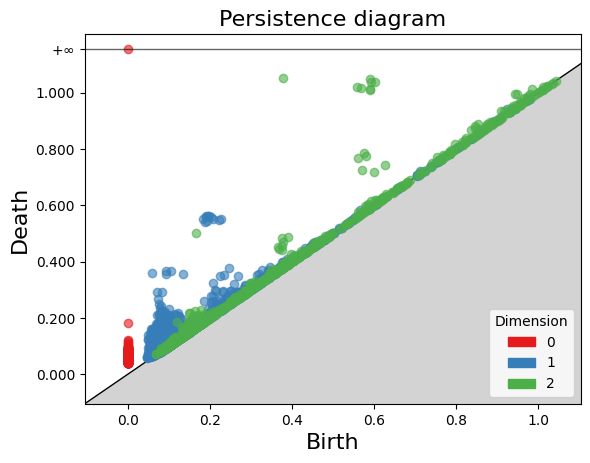

In [ ]:
from scipy.spatial.distance import cdist

def farthest_point_sampling(puntos, num_puntos_deseados):
    idx_seleccionados = [np.random.randint(0, len(puntos))]
    distancias_minimas = cdist(puntos[idx_seleccionados], puntos).squeeze()

    for _ in range(1, num_puntos_deseados):
        siguiente_idx = np.argmax(distancias_minimas)
        idx_seleccionados.append(siguiente_idx)
        # Actualizar distancias mínimas respecto al nuevo conjunto de puntos seleccionados
        nuevas_distancias = cdist(puntos[[siguiente_idx]], puntos).squeeze()
        distancias_minimas = np.minimum(distancias_minimas, nuevas_distancias)

    return puntos[idx_seleccionados]

# Uso:
nube_inteligente = farthest_point_sampling(nube_puntos, 1000)

# 3. Crear el complejo Alfa (crece muchísimo más lento que Vietoris-Rips)
alpha_complex = gd.AlphaComplex(points=nube_inteligente)
simplex_tree = alpha_complex.create_simplex_tree()

# 4. Calcular la persistencia
simplex_tree.compute_persistence()

# 5. Graficar el diagrama
gd.plot_persistence_diagram(simplex_tree.persistence())
plt.show()

yEste diagrama **tiene mucho mas sentido** mostrando muchos agujeros de 3D. Tarda 1min en hacerlo para 100.000 puntos, ya es una mejora considerable. quiero cambiar la estetica.

In [1]:
!pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 52.3 MB/s eta 0:00:00


In [2]:
"""
tda_engine_gudhi.py
===================
Versión del motor que usa la librería GUDHI para el complejo testigo y la
persistencia, en lugar de la implementación propia.

  pip install gudhi numpy scipy matplotlib

Qué pone GUDHI (en vez de mis funciones):
  - FPS de landmarks          -> gudhi.subsampling.choose_n_farthest_points
  - complejo testigo DÉBIL    -> gudhi.EuclideanWitnessComplex
  - complejo testigo FUERTE   -> gudhi.EuclideanStrongWitnessComplex
  - filtración + persistencia -> SimplexTree.create_simplex_tree(...).persistence()
  - números de Betti          -> SimplexTree.betti_numbers()

Qué sigue en numpy (GUDHI no lo ofrece):
  - local_pca_dim   : dimensión intrínseca local por PCA
  - spherical_kmeans: agrupar direcciones -> ejes (con identificación antipodal)

Nota de parámetros: GUDHI controla la escala con `max_alpha_square` (en unidades
de DISTANCIA AL CUADRADO / relajación), no con el "grado de vecindad" que yo usaba.
Aquí se ofrece `auto_max_alpha_square` para fijarlo a partir de la escala local.
"""
import numpy as np
import gudhi
import gudhi.subsampling
from scipy.spatial import cKDTree


# ----------------------------------------------------------------------
# 1. Landmarks por FPS  (GUDHI)
# ----------------------------------------------------------------------
def landmarks_fps(X, n, seed=0, cap=200000):
    """Selecciona n landmarks por farthest point sampling con GUDHI.
    Para nubes enormes, prerecorta aleatoriamente a `cap` puntos (el FPS es O(n·N))."""
    if len(X) > cap:
        X = X[np.random.default_rng(seed).choice(len(X), cap, replace=False)]
    L = gudhi.subsampling.choose_n_farthest_points(points=X, nb_points=min(n, len(X)))
    return np.asarray(L, dtype=float)


# ----------------------------------------------------------------------
# 2. Escala de filtración automática
# ----------------------------------------------------------------------
def auto_max_alpha_square(landmarks, factor=3.0):
    """max_alpha_square ~ (factor · distancia mediana al vecino más cercano)^2.
    Punto de partida razonable; súbelo si H1/H2 no llegan a formarse."""
    nn = cKDTree(landmarks).query(landmarks, k=2)[0][:, 1]
    return float((factor * np.median(nn)) ** 2)


# ----------------------------------------------------------------------
# 3. Complejo testigo + persistencia  (GUDHI)
# ----------------------------------------------------------------------
def witness_persistence(P, nland=200, nwit=30000, max_alpha_square=None,
                        limit_dimension=3, factor=3.0, coeff=2, strong=False, seed=0):
    """Pipeline completo con GUDHI. Devuelve (SimplexTree ya persistido,
    max_alpha_square usado, landmarks).
      - limit_dimension=3 -> incluye tetraedros, necesario para H2.
      - coeff             -> cuerpo Z/coeff. Usa 2 y 3 para detectar torsión (orientabilidad).
      - strong=True       -> usa el testigo FUERTE relajado (más rápido a filtración alta)."""
    rng = np.random.default_rng(seed)
    land = landmarks_fps(P, min(nland, len(P)), seed=seed)
    W = P if len(P) <= nwit else P[rng.choice(len(P), nwit, replace=False)]
    if max_alpha_square is None:
        max_alpha_square = auto_max_alpha_square(land, factor)

    Cls = gudhi.EuclideanStrongWitnessComplex if strong else gudhi.EuclideanWitnessComplex
    wc = Cls(landmarks=land.tolist(), witnesses=W.tolist())
    st = wc.create_simplex_tree(max_alpha_square=max_alpha_square,
                                limit_dimension=limit_dimension)
    st.persistence(homology_coeff_field=coeff, persistence_dim_max=False)
    return st, max_alpha_square, land


def betti(st):
    """Números de Betti (b0,b1,b2). Requiere haber llamado a persistence() antes."""
    b = list(st.betti_numbers())
    return tuple((b + [0, 0, 0])[:3])


def diagrams(st, maxdim=2):
    """Diagramas por dimensión como arrays (n,2) de (nacimiento, muerte).
    La muerte puede ser inf. El eje está en unidades de alpha^2."""
    return {p: st.persistence_intervals_in_dimension(p) for p in range(maxdim + 1)}


# ----------------------------------------------------------------------
# 4. Geometría local (numpy; GUDHI no lo provee)
# ----------------------------------------------------------------------
def local_pca_dim(points, ref, k=40, thr=0.12):
    """Dimensión local (1/2/3) de cada punto por PCA de sus k vecinos en `ref`."""
    tree = cKDTree(ref)
    _, nb = tree.query(points, k=k)
    dim = np.zeros(len(points)); evr = np.zeros((len(points), 3))
    for i in range(len(points)):
        Q = ref[nb[i]] - ref[nb[i]].mean(0)
        l = np.linalg.svd(Q, compute_uv=False) ** 2; l = l / l.sum()
        evr[i] = l; dim[i] = 1 + (l[1] > thr) + (l[2] > thr)
    return dim, evr


def spherical_kmeans(u, k, iters=60, seed=0):
    """k-means esférico con similitud |u·c| (identifica u con -u). Devuelve (ejes, etiquetas)."""
    rng = np.random.default_rng(seed)
    C = u[rng.choice(len(u), k, replace=False)].copy()
    for _ in range(iters):
        lab = np.abs(u @ C.T).argmax(1); newC = np.zeros_like(C)
        for j in range(k):
            pts = u[lab == j]
            if len(pts) < 3: newC[j] = C[j]; continue
            M = (pts[:, :, None] * pts[:, None, :]).sum(0)
            w, v = np.linalg.eigh(M); newC[j] = v[:, -1]
        if np.allclose(np.abs((newC * C).sum(1)), 1, atol=1e-4): C = newC; break
        C = newC
    return C, np.abs(u @ C.T).argmax(1)


# ----------------------------------------------------------------------
# Validación (ejecuta este archivo directamente para comprobar GUDHI)
# ----------------------------------------------------------------------
if __name__ == "__main__":
    rng = np.random.default_rng(1)
    u = rng.normal(0, 1, (8000, 3)); S = u / np.linalg.norm(u, axis=1, keepdims=True)
    st, a, _ = witness_persistence(S, nland=120, nwit=8000, factor=3.0)
    print(f"Esfera (max_alpha_square={a:.3f}) -> Betti {betti(st)}  (esperado (1,0,1))")
    a0, b0 = 2.0, 0.8
    th = rng.uniform(0, 2*np.pi, 8000); ph = rng.uniform(0, 2*np.pi, 8000)
    T = np.column_stack([(a0 + b0*np.cos(ph))*np.cos(th),
                         (a0 + b0*np.cos(ph))*np.sin(th), b0*np.sin(ph)])
    st, a, _ = witness_persistence(T, nland=160, nwit=8000, factor=3.0)
    print(f"Toro   (max_alpha_square={a:.3f}) -> Betti {betti(st)}  (esperado (1,2,1))")

Esfera (max_alpha_square=0.743) -> Betti (1, 0, 1)  (esperado (1,0,1))
Toro   (max_alpha_square=2.545) -> Betti (1, 1, 0)  (esperado (1,2,1))


El siguiente paso que quiero aplicar es el **analisis inverso, (hay que explicarlo en el fundamento teórico, tiene su miga)** consiste en recrear la forma de la nube de puntos a partir de su diagrama de persistencia.

**Usando homcloud**

Aún sigo peleandome con el código, sería conveniente incluir algu ejemplo más sencillo primero. **Digame si le parece una buena idea para ahondar o no en el tema  https://www.emergentmind.com/topics/inverse-problem-in-topological-data-analysis**

Prueba de HomCloud

In [ ]:
!pip install homcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.6/27.6 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.9/272.9 kB 20.0 MB/s eta 0:00:00


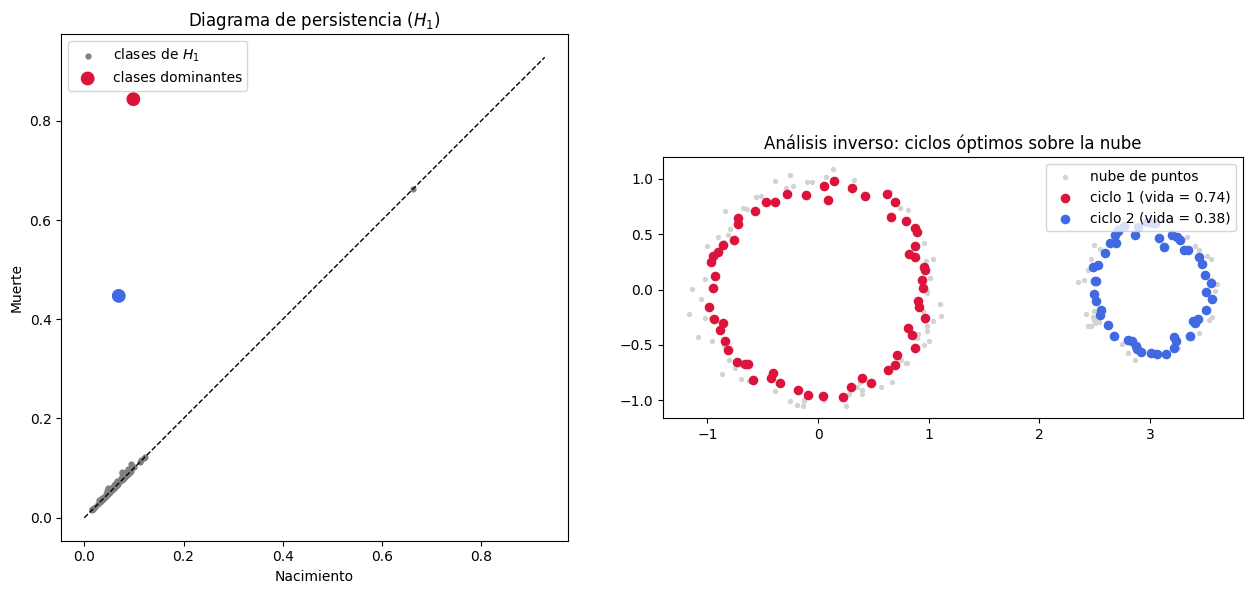

In [ ]:
# =====================================================================
#  ANÁLISIS INVERSO CON HOMCLOUD: localización de ciclos óptimos
#  (en Colab/Jupyter, instalar antes en una celda aparte:  !pip install homcloud)
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import homcloud.interface as hc

# ---------------------------------------------------------------------
# 1. NUBE DE PUNTOS: dos anillos ruidosos -> dos agujeros en H1
# ---------------------------------------------------------------------
rng = np.random.default_rng(0)

def anillo(n, centro, radio, ruido):
    ang = rng.uniform(0, 2 * np.pi, n)
    rad = radio + rng.normal(0, ruido, n)
    cx, cy = centro
    return np.column_stack((cx + rad * np.cos(ang), cy + rad * np.sin(ang)))

A = anillo(140, centro=(0.0, 0.0), radio=1.00, ruido=0.06)
B = anillo(90,  centro=(3.0, 0.0), radio=0.55, ruido=0.05)
puntos = np.vstack((A, B))

# ---------------------------------------------------------------------
# 2. HOMOLOGÍA PERSISTENTE (filtración alpha)
#    save_boundary_map=True  -> imprescindible para el análisis inverso
#    squared=False           -> nacimientos/muertes en unidades de distancia
# ---------------------------------------------------------------------
hc.PDList.from_alpha_filtration(puntos,
                                save_boundary_map=True,
                                squared=False,
                                save_to="dos_anillos.pdgm")

pd1 = hc.PDList("dos_anillos.pdgm").dth_diagram(1)   # diagrama de dimensión 1

# ---------------------------------------------------------------------
# 3. Las dos clases de H1 más persistentes (las dos más alejadas de la diagonal)
# ---------------------------------------------------------------------
vidas = pd1.deaths - pd1.births
top2 = np.argsort(-vidas)[:2]

# ---------------------------------------------------------------------
# 4. FIGURA: diagrama de persistencia + análisis inverso
# ---------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
colores = ['crimson', 'royalblue']

# --- (a) Diagrama de persistencia de H1 ---
ax1.scatter(pd1.births, pd1.deaths, s=12, c='gray', label=r'clases de $H_1$')
ax1.scatter(pd1.births[top2], pd1.deaths[top2], s=80, c=colores, zorder=3,
            label='clases dominantes')
lim = pd1.deaths.max() * 1.1
ax1.plot([0, lim], [0, lim], 'k--', lw=1)
ax1.set_xlabel("Nacimiento"); ax1.set_ylabel("Muerte")
ax1.set_title(r"Diagrama de persistencia ($H_1$)")
ax1.set_aspect('equal'); ax1.legend()

# --- (b) Análisis inverso: ciclo óptimo de cada clase dominante ---
ax2.scatter(puntos[:, 0], puntos[:, 1], s=8, c='lightgray', label='nube de puntos')
for k, idx in enumerate(top2):
    b, d = pd1.births[idx], pd1.deaths[idx]
    pair = pd1.nearest_pair_to(b, d)
    volumen = pair.optimal_volume()              # análisis inverso (sin parámetros)
    # volumen = pair.stable_volume(0.1)          # variante robusta al ruido (ajustar epsilon)
    ciclo = np.array(volumen.boundary_points())  # puntos que forman el ciclo
    ax2.scatter(ciclo[:, 0], ciclo[:, 1], s=35, c=colores[k], zorder=3,
                label=f'ciclo {k + 1} (vida = {d - b:.2f})')

ax2.set_aspect('equal'); ax2.legend()
ax2.set_title("Análisis inverso: ciclos óptimos sobre la nube")

plt.tight_layout()
plt.show()